
>>> Processing Region: North Pacific (Upper 300m) ...
  - Past files: 120 | Present files: 120

>>> Processing Region: North Atlantic (Upper 300m) ...
  - Past files: 120 | Present files: 120

>>> Displaying 2-row x 2-column comprehensive seasonality grid...


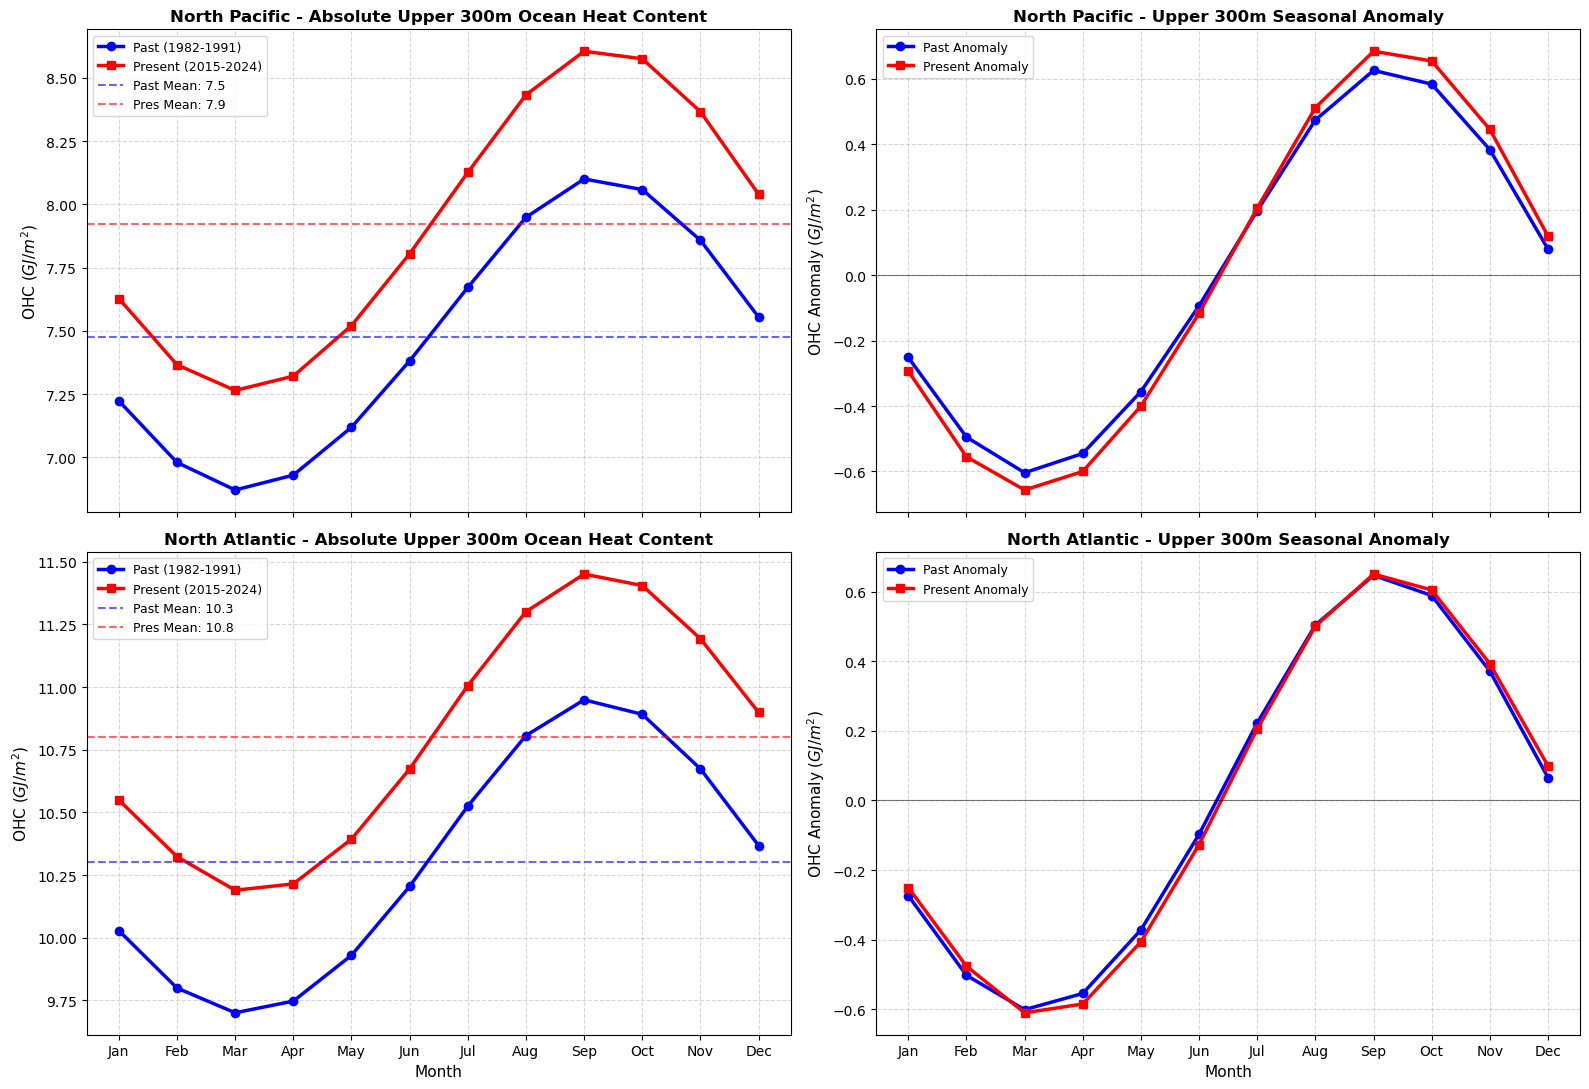


=== UPPER 300M OHC ANNUAL MEAN COMPARISON SUMMARY ===
[North Pacific]
  - Past (1982-1991) Annual Mean   : 7.47 GJ/m^2
  - Present (2015-2024) Annual Mean: 7.92 GJ/m^2
  - Baseline Net Warming Change    : +0.45 GJ/m^2

[North Atlantic]
  - Past (1982-1991) Annual Mean   : 10.30 GJ/m^2
  - Present (2015-2024) Annual Mean: 10.80 GJ/m^2
  - Baseline Net Warming Change    : +0.50 GJ/m^2



In [1]:
import os
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ==========================================
# 1. Path and Constant Configurations
# ==========================================
# Base directories for both regions
root_dir = '/nird/datalake/NS11071K/users/yongyub/ORAS5/potential_temperature'
regions = ['North_Pacific', 'North_Atlantic']

# Physical constants for Ocean Heat Content (OHC)
rho0 = 1025.0  # Seawater reference density (kg/m^3)
Cp = 3996.0    # Specific heat capacity of seawater (J/(kg*C))
max_depth = 300.0  # Integration depth limit (meters)

# Define the two 10-year periods for comparison
past_years = range(1982, 1992)      # 1982 ~ 1991 (10 years)
present_years = range(2015, 2025)   # 2015 ~ 2024 (10 years)

def get_file_list(region_name, years_range):
    """Helper function to collect all monthly netCDF files for given region and years"""
    files = []
    reg_dir = os.path.join(root_dir, region_name)
    for yr in years_range:
        # Matches files like North_Pacific_votemper_1x1_198201.nc or North_Atlantic_votemper_1x1_198201.nc
        year_pattern = os.path.join(reg_dir, str(yr), f"{region_name}_votemper_1x1_{yr}*.nc")
        files.extend(sorted(glob.glob(year_pattern)))
    return files

# ==========================================
# 2. OHC Calculation Core Function (Upper 300m Bounded)
# ==========================================
def calculate_ohc_seasonality_300m(file_list):
    """Loads datasets, computes Upper 300m OHC, spatial mean, and 12-month climatology"""
    ds = xr.open_mfdataset(file_list, combine='by_coords', chunks={'time_counter': 1, 'deptht': -1})
    
    T = ds['votemper']
    
    # 2.1 Calculate layer thickness (dz) from vertical depth centerpoints with 300m truncation
    depth = ds['deptht'].values
    bounds = np.zeros(len(depth) + 1)
    bounds[1:-1] = (depth[:-1] + depth[1:]) / 2.0
    bounds[0] = 0.0
    bounds[-1] = depth[-1] + (depth[-1] - bounds[-2])
    
    dz_full = np.diff(bounds)
    dz_300 = np.zeros_like(dz_full)
    
    for k in range(len(depth)):
        z_top = bounds[k]
        z_bot = bounds[k+1]
        
        if z_bot <= max_depth:
            # Entire layer is within upper 300m
            dz_300[k] = dz_full[k]
        elif z_top < max_depth and z_bot > max_depth:
            # Layer straddles the 300m line -> truncate thickness precisely at 300m
            dz_300[k] = max_depth - z_top
        else:
            # Layer is entirely below 300m
            dz_300[k] = 0.0
            
    dz = xr.DataArray(dz_300, dims=['deptht'], coords={'deptht': ds['deptht']})
    
    # Drop deeper layers where dz == 0 to save computational memory footprint
    T_300 = T.where(dz > 0, drop=True)
    dz_300_truncated = dz.where(dz > 0, drop=True)
    
    # 2.2 Vertical Integration for Upper 300m
    ohc_2d = (T_300 * dz_300_truncated).sum(dim='deptht', skipna=True) * rho0 * Cp
    
    # 2.3 Spatial Mean with Latitude Weighting (Accounts for converging meridians)
    weights = np.cos(np.deg2rad(ds['lat']))
    weights.name = "weights"
    ohc_weighted = ohc_2d.weighted(weights)
    ohc_timeseries = ohc_weighted.mean(dim=['lat', 'lon'], skipna=True)
    
    # 2.4 Compute Climatological Seasonality (12-month cycle)
    ohc_seasonality = ohc_timeseries.groupby('time_counter.month').mean(dim='time_counter')
    
    ohc_seasonality.load()
    ds.close()
    
    return ohc_seasonality

# ==========================================
# 3. Processing Data for All Regions
# ==========================================
results = {}

for reg in regions:
    print(f"\n>>> Processing Region: {reg.replace('_', ' ')} (Upper 300m) ...")
    past_files = get_file_list(reg, past_years)
    present_files = get_file_list(reg, present_years)
    
    print(f"  - Past files: {len(past_files)} | Present files: {len(present_files)}")
    
    ohc_past = calculate_ohc_seasonality_300m(past_files)
    ohc_present = calculate_ohc_seasonality_300m(present_files)
    
    # Scale to GJ/m^2 and compute anomalies
    past_gj = ohc_past / 1e9
    present_gj = ohc_present / 1e9
    
    mean_past = past_gj.mean()
    mean_present = present_gj.mean()
    
    results[reg] = {
        'past_gj': past_gj, 'present_gj': present_gj,
        'mean_past': mean_past, 'mean_present': mean_present,
        'anomaly_past': past_gj - mean_past,
        'anomaly_present': present_gj - mean_present
    }

# ==========================================
# 4. Render 2-Row x 2-Column Matrix Display
# ==========================================
print("\n>>> Displaying 2-row x 2-column comprehensive seasonality grid...")
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 11), sharex=True)

months_axis = np.arange(1, 13)
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for r_idx, reg in enumerate(regions):
    res = results[reg]
    title_prefix = "North Pacific" if reg == 'North_Pacific' else "North Atlantic"
    
    # -------------------------------------------------------------
    # Left Column: Absolute Climatological Seasonality
    # -------------------------------------------------------------
    ax_abs = axes[r_idx, 0]
    ax_abs.plot(months_axis, res['past_gj'], marker='o', color='blue', linewidth=2.5, label='Past (1982-1991)')
    ax_abs.plot(months_axis, res['present_gj'], marker='s', color='red', linewidth=2.5, label='Present (2015-2024)')
    
    # Reference annual mean lines
    ax_abs.axhline(res['mean_past'], color='blue', linestyle='--', alpha=0.6, label=f"Past Mean: {res['mean_past']:.1f}")
    ax_abs.axhline(res['mean_present'], color='red', linestyle='--', alpha=0.6, label=f"Pres Mean: {res['mean_present']:.1f}")
    
    ax_abs.set_title(f"{title_prefix} - Absolute Upper 300m Ocean Heat Content", fontsize=12, weight='bold')
    ax_abs.set_ylabel('OHC ($GJ / m^2$)', fontsize=11)
    ax_abs.grid(True, linestyle='--', alpha=0.5)
    ax_abs.legend(fontsize=9, loc='best')
    
    # -------------------------------------------------------------
    # Right Column: Seasonal Anomalies (Relative to own annual mean)
    # -------------------------------------------------------------
    ax_anom = axes[r_idx, 1]
    ax_anom.plot(months_axis, res['anomaly_past'], marker='o', color='blue', linewidth=2.5, label='Past Anomaly')
    ax_anom.plot(months_axis, res['anomaly_present'], marker='s', color='red', linewidth=2.5, label='Present Anomaly')
    ax_anom.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
    
    ax_anom.set_title(f"{title_prefix} - Upper 300m Seasonal Anomaly", fontsize=12, weight='bold')
    ax_anom.set_ylabel('OHC Anomaly ($GJ / m^2$)', fontsize=11)
    ax_anom.grid(True, linestyle='--', alpha=0.5)
    ax_anom.legend(fontsize=9, loc='best')

# Set bottom X-axis labels for both columns
for col_idx in range(2):
    axes[1, col_idx].set_xlabel('Month', fontsize=11)
    axes[1, col_idx].set_xticks(months_axis)
    axes[1, col_idx].set_xticklabels(month_labels)

plt.tight_layout()
plt.show()

# Print text summary report
print("\n=== UPPER 300M OHC ANNUAL MEAN COMPARISON SUMMARY ===")
for reg in regions:
    res = results[reg]
    print(f"[{reg.replace('_', ' ')}]")
    print(f"  - Past (1982-1991) Annual Mean   : {res['mean_past'].values:.2f} GJ/m^2")
    print(f"  - Present (2015-2024) Annual Mean: {res['mean_present'].values:.2f} GJ/m^2")
    print(f"  - Baseline Net Warming Change    : {res['mean_present'].values - res['mean_past'].values:+.2f} GJ/m^2\n")

In [2]:
import numpy as np
import xarray as xr

def calculate_asymmetry_indices(ohc_seasonality):
    """
    Performs Fourier Analysis on 12-month OHC climatology 
    to extract A1, A2, phi1, phi2 and compute |DAI| and |PAI|.
    """
    # 1. Ensure data is a 1D array of length 12
    data = ohc_seasonality.values.squeeze()
    if len(data) != 12:
        raise ValueError("Input seasonality must have exactly 12 monthly values.")
        
    # 2. Perform Discrete Fourier Transform (DFT)
    dft_coeffs = np.fft.fft(data)
    
    # N=12 normalization factor (FFT in numpy requires 2/N for non-zero frequencies)
    # Harmonic 1 (Annual cycle): index 1
    # Harmonic 2 (Semi-annual cycle): index 2
    h1 = dft_coeffs[1] * (2.0 / 12.0)
    h2 = dft_coeffs[2] * (2.0 / 12.0)
    
    # 3. Extract Amplitudes (A1, A2)
    A1 = np.abs(h1)
    A2 = np.abs(h2)
    
    # 4. Extract Phases (phi1, phi2) in radians
    # np.angle returns values in range [-pi, pi]. 
    # Using negative sign matches standard standard mathematical representation: cos(omega*t - phi)
    phi1 = -np.angle(h1)
    phi2 = -np.angle(h2)
    
    # 5. Compute Asymmetry Phase Parameter (Theta = 2*phi1 - phi2)
    theta = 2 * phi1 - phi2
    
    # 6. Calculate Magnitude Indices
    amplitude_ratio = A2 / A1
    DAI_mag = amplitude_ratio * np.abs(np.sin(theta))
    PAI_mag = amplitude_ratio * np.abs(np.cos(theta))
    
    return {
        'A1': A1, 'A2': A2, 
        'phi1': np.degrees(phi1) % 360, 'phi2': np.degrees(phi2) % 360, # converted to degrees for display
        'DAI_mag': DAI_mag, 'PAI_mag': PAI_mag
    }

# ==========================================
# Run Asymmetry Analysis for Both Regions (Upper 300m OHC)
# ==========================================
print("=== Computing Asymmetry Indices (|DAI| & |PAI|) for Upper 300m OHC ===")

# Loop through the pre-computed 300m results from the 2-row x 2-column step
for reg in ['North_Pacific', 'North_Atlantic']:
    reg_label = reg.replace('_', ' ')
    res = results[reg]
    
    # Pass the standard 12-month 300m climatology to the function
    idx_past = calculate_asymmetry_indices(res['past_gj'] * 1e9)     # convert back to J/m^2 for uniform function handling
    idx_present = calculate_asymmetry_indices(res['present_gj'] * 1e9)
    
    # Print Structured Results Table per Region
    print("\n" + "="*55)
    print(f"  [ REGION: {reg_label.upper()} (UPPER 300M) ]")
    print("="*55)
    print(f"{'Metric':<15} | {'Past (1982-1991)':<18} | {'Present (2015-2024)':<18}")
    print("-"*55)
    print(f"{'A1 (Annual)':<15} | {idx_past['A1']/1e9:16.4f} | {idx_present['A1']/1e9:16.4f} GJ/m^2")
    print(f"{'A2 (Semi-Ann)':<15} | {idx_past['A2']/1e9:16.4f} | {idx_present['A2']/1e9:16.4f} GJ/m^2")
    print(f"{'A2 / A1 Ratio':<15} | {idx_past['A2']/idx_past['A1']:16.4f} | {idx_present['A2']/idx_present['A1']:16.4f}")
    print(f"{'phi1 (deg)':<15} | {idx_past['phi1']:16.2f}° | {idx_present['phi1']:16.2f}°")
    print(f"{'phi2 (deg)':<15} | {idx_past['phi2']:16.2f}° | {idx_present['phi2']:16.2f}°")
    print("-"*55)
    print(f"{'|DAI| Magnitude':<15} | \033[1;34m{idx_past['DAI_mag']:16.4f}\033[0m | \033[1;31m{idx_present['DAI_mag']:16.4f}\033[0m")
    print(f"{'|PAI| Magnitude':<15} | \033[1;34m{idx_past['PAI_mag']:16.4f}\033[0m | \033[1;31m{idx_present['PAI_mag']:16.4f}\033[0m")
    print("="*55)

=== Computing Asymmetry Indices (|DAI| & |PAI|) for Upper 300m OHC ===

  [ REGION: NORTH PACIFIC (UPPER 300M) ]
Metric          | Past (1982-1991)   | Present (2015-2024)
-------------------------------------------------------
A1 (Annual)     |           0.6125 |           0.6788 GJ/m^2
A2 (Semi-Ann)   |           0.0227 |           0.0344 GJ/m^2
A2 / A1 Ratio   |           0.0370 |           0.0507
phi1 (deg)      |           247.90° |           248.90°
phi2 (deg)      |           184.66° |           195.43°
-------------------------------------------------------
|DAI| Magnitude |           0.0279 |           0.0429
|PAI| Magnitude |           0.0244 |           0.0272

  [ REGION: NORTH ATLANTIC (UPPER 300M) ]
Metric          | Past (1982-1991)   | Present (2015-2024)
-------------------------------------------------------
A1 (Annual)     |           0.6267 |           0.6367 GJ/m^2
A2 (Semi-Ann)   |           0.0234 |           0.0202 GJ/m^2
A2 / A1 Ratio   |           0.0374 |    

>>> Computing Annual A2/A1 Ratio Timeseries for Upper 300m (1982-2024)...
  - Processing Region: North Pacific
  - Processing Region: North Atlantic

>>> Plotting unified A2/A1 ratio timeseries...


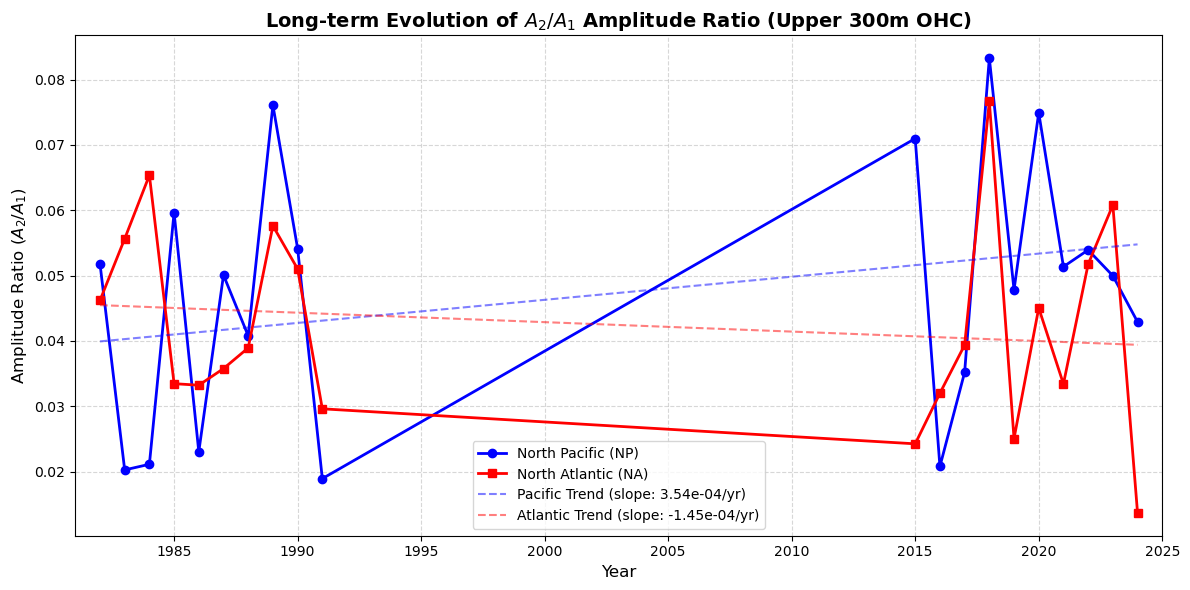

In [3]:
import os
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ==========================================
# 1. Path and Multi-Year Configurations
# ==========================================
root_dir = '/nird/datalake/NS11071K/users/yongyub/ORAS5/potential_temperature'
regions = ['North_Pacific', 'North_Atlantic']

all_years = range(1982, 2025)  # 1982 ~ 2024 (43 years)

# Physical constants for Ocean Heat Content
rho0 = 1025.0
Cp = 3996.0
max_depth = 300.0  # Integration depth limit (meters)

def get_single_year_files(region_name, target_year):
    """Collects exactly 12 monthly files for a specific year and region"""
    reg_dir = os.path.join(root_dir, region_name)
    year_pattern = os.path.join(reg_dir, str(target_year), f"{region_name}_votemper_1x1_{target_year}*.nc")
    return sorted(glob.glob(year_pattern))

# Initialize storage for timeseries
ratio_timeseries = {reg: [] for reg in regions}
valid_years = {reg: [] for reg in regions}

# ==========================================
# 2. Annual Loop for Fourier Ratio Extraction (Upper 300m)
# ==========================================
print(">>> Computing Annual A2/A1 Ratio Timeseries for Upper 300m (1982-2024)...")

for reg in regions:
    print(f"  - Processing Region: {reg.replace('_', ' ')}")
    
    for yr in all_years:
        files = get_single_year_files(reg, yr)
        
        # Check if a full year (12 months) of data exists to perform valid annual FFT
        if len(files) != 12:
            continue
            
        # Open 12 months for the single year
        ds = xr.open_mfdataset(files, combine='by_coords', chunks={'time_counter': 1, 'deptht': -1})
        
        # 2.1 Calculate layer thickness (dz) with precise 300m truncation
        depth = ds['deptht'].values
        bounds = np.zeros(len(depth) + 1)
        bounds[1:-1] = (depth[:-1] + depth[1:]) / 2.0
        bounds[0] = 0.0
        bounds[-1] = depth[-1] + (depth[-1] - bounds[-2])
        
        dz_full = np.diff(bounds)
        dz_300 = np.zeros_like(dz_full)
        
        for k in range(len(depth)):
            z_top = bounds[k]
            z_bot = bounds[k+1]
            
            if z_bot <= max_depth:
                dz_300[k] = dz_full[k]
            elif z_top < max_depth and z_bot > max_depth:
                dz_300[k] = max_depth - z_top
            else:
                dz_300[k] = 0.0
                
        dz = xr.DataArray(dz_300, dims=['deptht'], coords={'deptht': ds['deptht']})
        
        # Drop deeper layers to optimize computational memory and speed
        T_300 = ds['votemper'].where(dz > 0, drop=True)
        dz_300_truncated = dz.where(dz > 0, drop=True)
        
        # 2.2 Calculate Spatial Area-Weighted Mean Timeseries for Upper 300m
        ohc_2d = (T_300 * dz_300_truncated).sum(dim='deptht', skipna=True) * rho0 * Cp
        weights = np.cos(np.deg2rad(ds['lat']))
        weights.name = "weights"
        ohc_1d = ohc_2d.weighted(weights).mean(dim=['lat', 'lon'], skipna=True).load()
        
        ds.close()
        
        # 2.3 Perform FFT on the 12-month array
        data_12months = ohc_1d.values.squeeze()
        dft_coeffs = np.fft.fft(data_12months)
        
        # Extract Amplitudes for Harmonic 1 and Harmonic 2
        A1 = np.abs(dft_coeffs[1] * (2.0 / 12.0))
        A2 = np.abs(dft_coeffs[2] * (2.0 / 12.0))
        
        # Compute the ratio and store
        if A1 > 0:  # Prevent potential zero-division on corrupted steps
            annual_ratio = A2 / A1
            ratio_timeseries[reg].append(annual_ratio)
            valid_years[reg].append(yr)

# ==========================================
# 3. Single-Panel Comparison Plot
# ==========================================
print("\n>>> Plotting unified A2/A1 ratio timeseries...")
plt.figure(figsize=(12, 6))

# Plot North Pacific (NP)
plt.plot(valid_years['North_Pacific'], ratio_timeseries['North_Pacific'], 
         marker='o', color='blue', linewidth=2, label='North Pacific (NP)')

# Plot North Atlantic (NA)
plt.plot(valid_years['North_Atlantic'], ratio_timeseries['North_Atlantic'], 
         marker='s', color='red', linewidth=2, label='North Atlantic (NA)')

# Add linear trendlines to see long-term structural changes
for reg, color in zip(regions, ['blue', 'red']):
    x = np.array(valid_years[reg])
    y = np.array(ratio_timeseries[reg])
    if len(x) > 0:
        slope, intercept = np.polyfit(x, y, 1)
        reg_label = 'Pacific' if 'Pacific' in reg else 'Atlantic'
        plt.plot(x, slope*x + intercept, color=color, linestyle='--', alpha=0.5, 
                 label=f"{reg_label} Trend (slope: {slope:.2e}/yr)")

# Plot adjustments
plt.title('Long-term Evolution of $A_2 / A_1$ Amplitude Ratio (Upper 300m OHC)', fontsize=14, weight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Amplitude Ratio ($A_2 / A_1$)', fontsize=12)
plt.xlim(1981, 2025)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10, loc='best')

plt.tight_layout()
plt.show()

In [4]:
import os
import glob
import numpy as np
import xarray as xr

# ==========================================
# 1. Path and Data Configurations (North Pacific)
# ==========================================
print(">>> Collecting file paths for North Pacific...")
# Use the Pacific file lists from prior cells
past_files_pac = get_file_list('North_Pacific', past_years)
present_files_pac = get_file_list('North_Pacific', present_years)

print(f"  - Pacific Past files: {len(past_files_pac)} | Present files: {len(present_files_pac)}")

print("\n>>> Loading full 4D datasets for North Pacific grid-point analysis...")
ds_past_pac = xr.open_mfdataset(past_files_pac, combine='by_coords', chunks={'time_counter': 1, 'deptht': -1})
ds_present_pac = xr.open_mfdataset(present_files_pac, combine='by_coords', chunks={'time_counter': 1, 'deptht': -1})

# Extract horizontal coordinates specific to the North Pacific domain
lon_pac = ds_past_pac['lon'].values
lat_pac = ds_past_pac['lat'].values
ny_pac, nx_pac = len(lat_pac), len(lon_pac)

# Calculate layer thickness (dz) from vertical depth centerpoints with 300m truncation
depth_pac = ds_past_pac['deptht'].values
bounds_pac = np.zeros(len(depth_pac) + 1)
bounds_pac[1:-1] = (depth_pac[:-1] + depth_pac[1:]) / 2.0
bounds_pac[0] = 0.0
bounds_pac[-1] = depth_pac[-1] + (depth_pac[-1] - bounds_pac[-2])

dz_full_pac = np.diff(bounds_pac)
dz_300_pac = np.zeros_like(dz_full_pac)
max_depth = 300.0  # Integration depth limit (meters)

for k in range(len(depth_pac)):
    z_top = bounds_pac[k]
    z_bot = bounds_pac[k+1]
    
    if z_bot <= max_depth:
        # Entire layer is within upper 300m
        dz_300_pac[k] = dz_full_pac[k]
    elif z_top < max_depth and z_bot > max_depth:
        # Layer straddles the 300m line -> truncate thickness precisely at 300m
        dz_300_pac[k] = max_depth - z_top
    else:
        # Layer is entirely below 300m
        dz_300_pac[k] = 0.0

dz_pac = xr.DataArray(dz_300_pac, dims=['deptht'], coords={'deptht': ds_past_pac['deptht']})

# Calculate Upper 300m OHC map time-series (dropping deeper layers where dz == 0)
print("  - Computing Upper 300m vertical integration for each Pacific grid point...")
T_past_300 = ds_past_pac['votemper'].where(dz_pac > 0, drop=True)
T_present_300 = ds_present_pac['votemper'].where(dz_pac > 0, drop=True)
dz_truncated_pac = dz_pac.where(dz_pac > 0, drop=True)

ohc_past_2d_pac = (T_past_300 * dz_truncated_pac).sum(dim='deptht', skipna=True) * rho0 * Cp
ohc_present_2d_pac = (T_present_300 * dz_truncated_pac).sum(dim='deptht', skipna=True) * rho0 * Cp

# Compute 12-month climatology maps (resulting shape: 12 x lat x lon)
print("  - Generating 12-month Upper 300m climatology grids for Pacific...")
clim_past_pac = ohc_past_2d_pac.groupby('time_counter.month').mean(dim='time_counter').load()
clim_present_pac = ohc_present_2d_pac.groupby('time_counter.month').mean(dim='time_counter').load()

ds_past_pac.close()
ds_present_pac.close()

# ==========================================
# 2. Grid-Point FFT and Asymmetry Extraction
# ==========================================
def compute_asymmetry_maps_pac(clim_grid, ny, nx):
    """Vectorized calculation of |DAI| and |PAI| maps optimized for Pacific dimensions"""
    data_3d = clim_grid.values
    data_flat = data_3d.reshape(12, -1)
    
    # Store land mask to restore shape later (where annual mean is NaN)
    land_mask = np.isnan(data_flat.mean(axis=0))
    
    # Fill NaNs temporarily with 0 to prevent FFT corruption on land cells
    data_flat_filled = np.nan_to_num(data_flat, nan=0.0)
    
    # Apply 1D FFT along the monthly axis (axis=0)
    dft_coeffs = np.fft.fft(data_flat_filled, axis=0)
    
    # Harmonic normalization (2 / N)
    h1 = dft_coeffs[1, :] * (2.0 / 12.0)
    h2 = dft_coeffs[2, :] * (2.0 / 12.0)
    
    A1 = np.abs(h1)
    A2 = np.abs(h2)
    
    phi1 = -np.angle(h1)
    phi2 = -np.angle(h2)
    
    theta = 2 * phi1 - phi2
    
    # Avoid zero-division errors over extreme land/missing grids safely
    with np.errstate(divide='ignore', invalid='ignore'):
        amp_ratio = A2 / A1
        dai = amp_ratio * np.abs(np.sin(theta))
        pai = amp_ratio * np.abs(np.cos(theta))
    
    # Re-apply the original ocean-land mask
    dai[land_mask] = np.nan
    pai[land_mask] = np.nan
    
    # Reshape back to the specific Pacific 2D spatial grid maps
    return dai.reshape(ny, nx), pai.reshape(ny, nx)

print("\n>>> Executing spatial Fourier transform maps for North Pacific...")
dai_past_pac, pai_past_pac = compute_asymmetry_maps_pac(clim_past_pac, ny_pac, nx_pac)
dai_present_pac, pai_present_pac = compute_asymmetry_maps_pac(clim_present_pac, ny_pac, nx_pac)

# Calculate the differences (Present minus Past) for North Pacific
dai_diff_pac = dai_present_pac - dai_past_pac
pai_diff_pac = pai_present_pac - pai_past_pac

print("=== Pacific Grid-Point FFT Computations Completed Successfully! ===")
print("Variables generated: 'dai_past_pac', 'pai_past_pac', 'dai_diff_pac', 'pai_diff_pac' etc.")

>>> Collecting file paths for North Pacific...
  - Pacific Past files: 120 | Present files: 120

>>> Loading full 4D datasets for North Pacific grid-point analysis...
  - Computing Upper 300m vertical integration for each Pacific grid point...
  - Generating 12-month Upper 300m climatology grids for Pacific...

>>> Executing spatial Fourier transform maps for North Pacific...
=== Pacific Grid-Point FFT Computations Completed Successfully! ===
Variables generated: 'dai_past_pac', 'pai_past_pac', 'dai_diff_pac', 'pai_diff_pac' etc.


>>> Visualizing 3x2 Asymmetry Spatial Matrix for North Pacific (Upper 300m)...


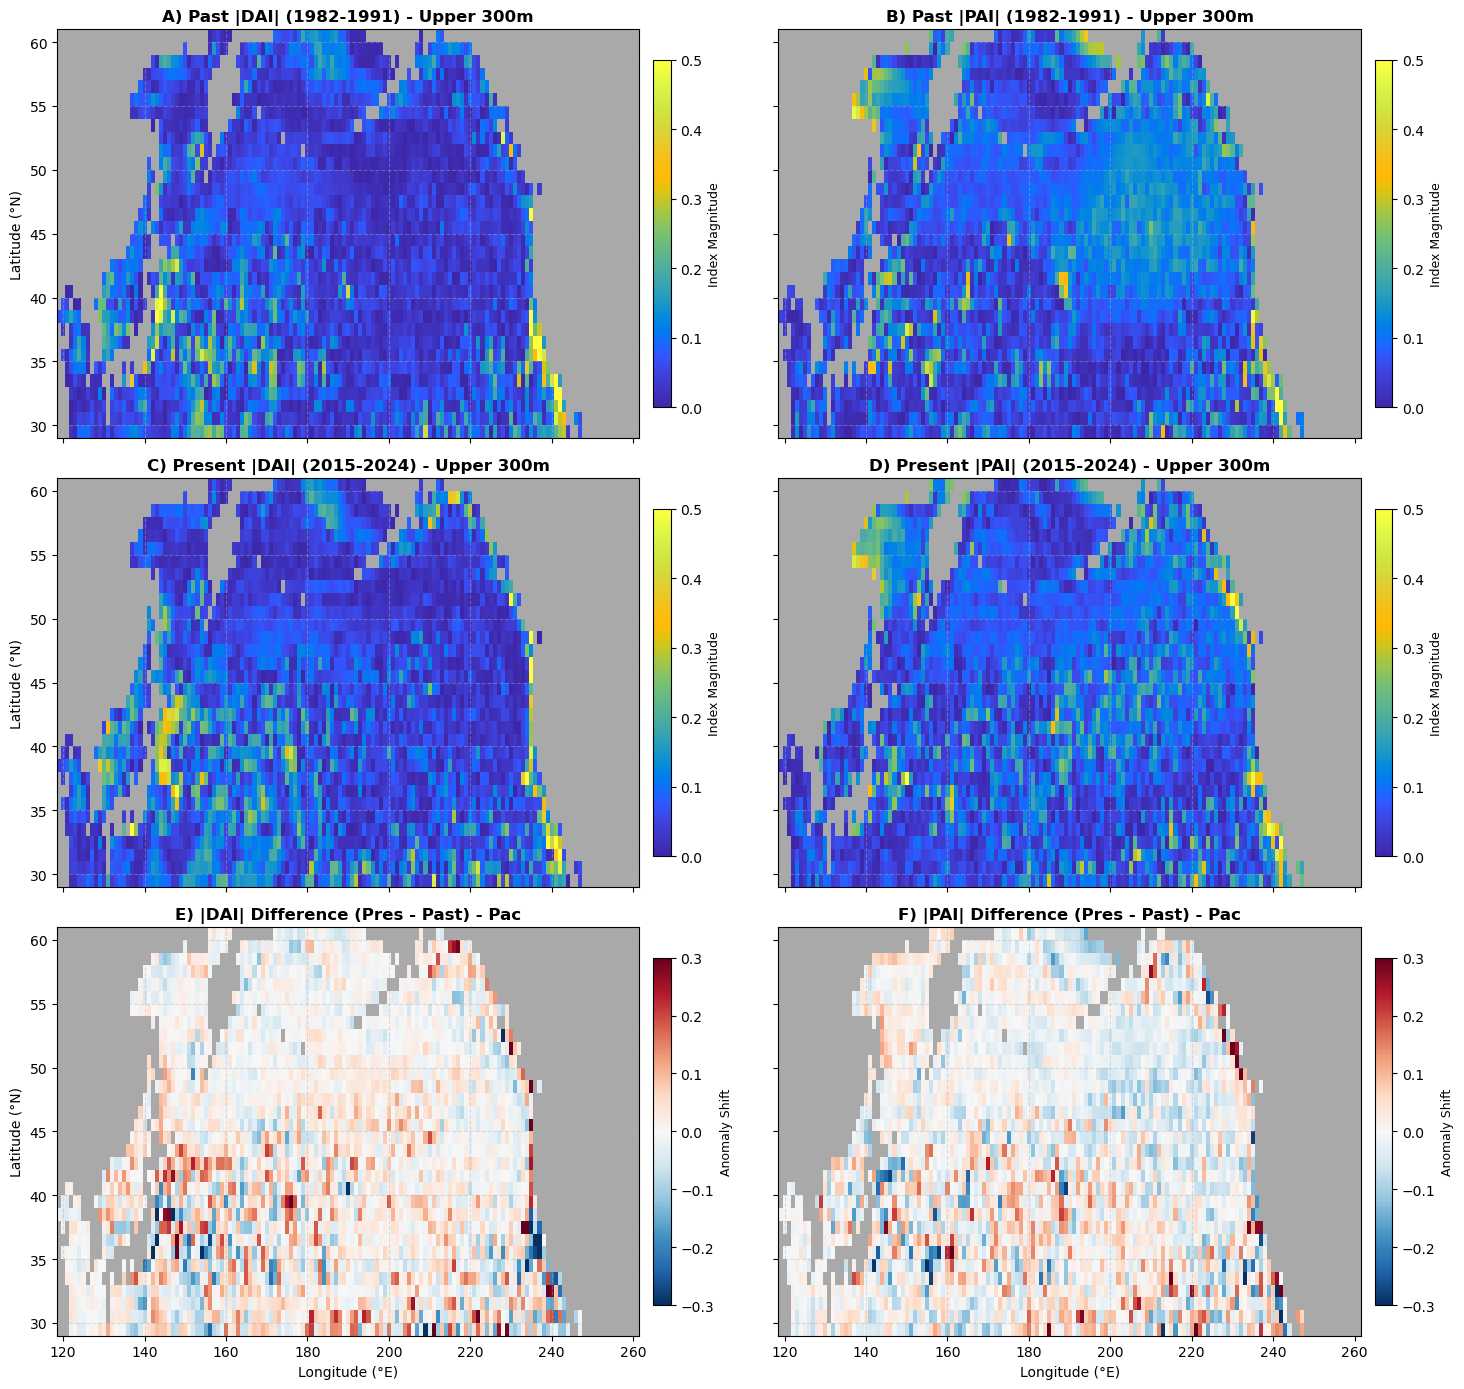

In [5]:
# ==========================================
# 3. Create Custom Parula Colormap & Render North Pacific Matrix (Upper 300m)
# ==========================================
print(">>> Visualizing 3x2 Asymmetry Spatial Matrix for North Pacific (Upper 300m)...")

# 3.1 Define Custom Parula RGB Data (MATLAB Standard)
from matplotlib.colors import LinearSegmentedColormap

parula_data = [
    [0.2422, 0.1504, 0.6603], [0.2444, 0.1793, 0.7107], [0.2464, 0.2062, 0.7621],
    [0.2464, 0.2336, 0.8166], [0.2406, 0.2631, 0.8735], [0.2243, 0.2974, 0.9328],
    [0.1925, 0.3372, 0.9852], [0.1345, 0.3842, 0.9996], [0.0637, 0.4337, 0.9822],
    [0.0150, 0.4795, 0.9429], [0.0076, 0.5204, 0.8936], [0.0381, 0.5557, 0.8430],
    [0.0886, 0.5855, 0.7960], [0.1437, 0.6111, 0.7523], [0.1966, 0.6338, 0.7115],
    [0.2448, 0.6548, 0.6724], [0.2878, 0.6749, 0.6336], [0.3275, 0.6946, 0.5941],
    [0.3662, 0.7137, 0.5529], [0.4068, 0.7317, 0.5085], [0.4526, 0.7481, 0.4593],
    [0.5061, 0.7621, 0.4035], [0.5694, 0.7725, 0.3396], [0.6433, 0.7785, 0.2666],
    [0.7275, 0.7789, 0.1856], [0.8193, 0.7719, 0.1065], [0.9120, 0.7561, 0.0453],
    [0.9873, 0.7384, 0.0248], [0.9959, 0.7337, 0.0415], [0.9806, 0.7445, 0.0766],
    [0.9507, 0.7628, 0.1171], [0.9150, 0.7854, 0.1557], [0.8809, 0.8105, 0.1895],
    [0.8533, 0.8369, 0.2173], [0.8339, 0.8637, 0.2384], [0.8242, 0.8904, 0.2530],
    [0.8258, 0.9163, 0.2618], [0.8398, 0.9404, 0.2657], [0.8664, 0.9619, 0.2657],
    [0.9044, 0.9800, 0.2625], [0.9515, 0.9933, 0.2570], [0.9965, 0.9977, 0.2443]
]
parula_cmap = LinearSegmentedColormap.from_list('parula', parula_data, N=256)
diff_cmap = 'RdBu_r'

# 3.2 Main Figure Framing
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 14), sharex=True, sharey=True)

# Fixed: Generate meshgrid using specific North Pacific horizontal coordinates (_pac)
lon_grid_pac, lat_grid_pac = np.meshgrid(lon_pac, lat_pac)

# Unified Range Setup
vmax_idx = 0.5    
vmax_diff = 0.3

# Fixed: Subplot rendering mapped strictly to North Pacific computed arrays (_pac)
plots_config = [
    # Row 1: Past State (North Pacific 300m)
    {'data': dai_past_pac,    'ax': axes[0, 0], 'cmap': parula_cmap, 'vmin': 0.0,         'vmax': vmax_idx,  'title': 'A) Past |DAI| (1982-1991) - Upper 300m'},
    {'data': pai_past_pac,    'ax': axes[0, 1], 'cmap': parula_cmap, 'vmin': 0.0,         'vmax': vmax_idx,  'title': 'B) Past |PAI| (1982-1991) - Upper 300m'},
    # Row 2: Present State (North Pacific 300m)
    {'data': dai_present_pac, 'ax': axes[1, 0], 'cmap': parula_cmap, 'vmin': 0.0,         'vmax': vmax_idx,  'title': 'C) Present |DAI| (2015-2024) - Upper 300m'},
    {'data': pai_present_pac, 'ax': axes[1, 1], 'cmap': parula_cmap, 'vmin': 0.0,         'vmax': vmax_idx,  'title': 'D) Present |PAI| (2015-2024) - Upper 300m'},
    # Row 3: Climate Change Shift (Present - Past)
    {'data': dai_diff_pac,    'ax': axes[2, 0], 'cmap': diff_cmap,   'vmin': -vmax_diff, 'vmax': vmax_diff, 'title': 'E) |DAI| Difference (Pres - Past) - Pac'},
    {'data': pai_diff_pac,    'ax': axes[2, 1], 'cmap': diff_cmap,   'vmin': -vmax_diff, 'vmax': vmax_diff, 'title': 'F) |PAI| Difference (Pres - Past) - Pac'}
]

for p in plots_config:
    ax = p['ax']
    # Fixed: Passing correct Pacific grid mesh coordinates
    mesh = ax.pcolormesh(lon_grid_pac, lat_grid_pac, p['data'], cmap=p['cmap'], vmin=p['vmin'], vmax=p['vmax'], shading='auto')
    ax.set_title(p['title'], fontsize=12, weight='bold')
    
    cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', pad=0.02, shrink=0.85)
    if 'Difference' in p['title']:
        cbar.set_label('Anomaly Shift', fontsize=9)
    else:
        cbar.set_label('Index Magnitude', fontsize=9)

# Standardize axis decorations for the entire matrix frame
for ax in axes.flatten():
    ax.set_facecolor('darkgray') # Highlights landmask areas beautifully
    ax.grid(True, linestyle='--', alpha=0.4)

# Apply specific labels only to boundary edges to keep plot uncluttered
for row in range(3):
    axes[row, 0].set_ylabel('Latitude (°N)', fontsize=10)
for col in range(2):
    axes[2, col].set_xlabel('Longitude (°E)', fontsize=10)

plt.tight_layout()
plt.show()

>>> Extracting Upper 300m seasonal cycle for single grid point [160.0E, 30.0N]...


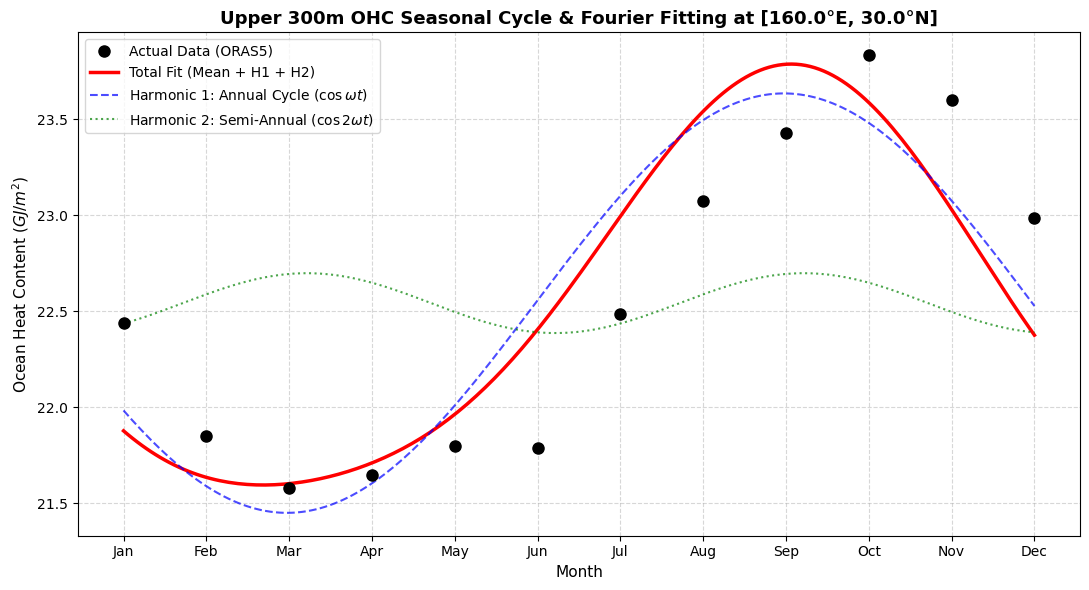


=== DIAGNOSTIC PARAMETERS (UPPER 300M) ===
  - Annual Amplitude (A1)     : 1.092 GJ/m^2
  - Semi-Annual Amplitude (A2): 0.156 GJ/m^2
  - Amplitude Ratio (A2/A1)   : 0.1428
  - Asymmetry Phase (Theta)   : 345.54°
  - Calculated |DAI| Magnitude: 0.0357
  - Calculated |PAI| Magnitude: 0.1383


In [6]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ==========================================
# 1. Target Grid Point Selection (160E, 30N)
# ==========================================
target_lon = 160.0
target_lat = 30.0

print(f">>> Extracting Upper 300m seasonal cycle for single grid point [{target_lon}E, {target_lat}N]...")

# Fixed: Using the newly computed Upper 300m North Pacific climatology array (_pac)
# Swap 'clim_present_pac' with 'clim_past_pac' to check the past period (1982-1991)
point_data = clim_present_pac.sel(lon=target_lon, lat=target_lat, method='nearest').values

# 12-month coordinates
months = np.arange(1, 13)

# ==========================================
# 2. Fourier Analysis & Continuous Reconstruction
# ==========================================
# Compute FFT
dft_coeffs = np.fft.fft(point_data)

# Mean state (A0)
A0 = dft_coeffs[0].real / 12.0

# Extract Components (Amplitudes and Phases)
h1 = dft_coeffs[1] * (2.0 / 12.0)
h2 = dft_coeffs[2] * (2.0 / 12.0)

A1 = np.abs(h1)
A2 = np.abs(h2)

phi1 = -np.angle(h1)
phi2 = -np.angle(h2)

# Generate high-resolution continuous time axis for a smooth fitting curve (1 to 12)
t_fine = np.linspace(1, 12, 200)
omega = 2 * np.pi / 12.0

# Reconstruct individual fitting curves (scaled to GJ/m^2)
scale = 1e9
fit_annual = (A1 * np.cos(omega * t_fine - phi1)) / scale
fit_semiannual = (A2 * np.cos(2 * omega * t_fine - phi2)) / scale
fit_total = (A0 + A1 * np.cos(omega * t_fine - phi1) + A2 * np.cos(2 * omega * t_fine - phi2)) / scale

# Actual Data scaled to GJ/m^2
actual_gj = point_data / scale

# ==========================================
# 3. Plotting the Fitting Curves
# ==========================================
plt.figure(figsize=(11, 6))

# Plot 1: Actual monthly data points
plt.plot(months, actual_gj, 'ko', markersize=8, label='Actual Data (ORAS5)', zorder=5)

# Plot 2: Total Fitted Curve (A0 + H1 + H2)
plt.plot(t_fine, fit_total, 'r-', linewidth=2.5, label='Total Fit (Mean + H1 + H2)')

# Plot 3: Pure Annual Cycle (H1, centered around the mean for structural mapping)
plt.plot(t_fine, (A0 / scale) + fit_annual, 'b--', linewidth=1.5, alpha=0.7, label='Harmonic 1: Annual Cycle ($\cos \omega t$)')

# Plot 4: Pure Semi-annual Cycle (H2, shifted to show secondary wave fluctuation)
plt.plot(t_fine, fit_semiannual + (actual_gj.mean()), 'g:', linewidth=1.5, alpha=0.7, label='Harmonic 2: Semi-Annual ($\cos 2\omega t$)')

# Formatting labels and details
plt.title(f'Upper 300m OHC Seasonal Cycle & Fourier Fitting at [{target_lon}°E, {target_lat}°N]', fontsize=13, weight='bold')
plt.xlabel('Month', fontsize=11)
plt.ylabel('Ocean Heat Content ($GJ / m^2$)', fontsize=11)
plt.xticks(months, ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10, loc='best')

plt.tight_layout()
plt.show()

# Print diagnostics out to check theta alignment
theta = 2 * phi1 - phi2
print("\n=== DIAGNOSTIC PARAMETERS (UPPER 300M) ===")
print(f"  - Annual Amplitude (A1)     : {A1/scale:.3f} GJ/m^2")
print(f"  - Semi-Annual Amplitude (A2): {A2/scale:.3f} GJ/m^2")
print(f"  - Amplitude Ratio (A2/A1)   : {A2/A1:.4f}")
print(f"  - Asymmetry Phase (Theta)   : {np.degrees(theta)%360:.2f}°")
print(f"  - Calculated |DAI| Magnitude: { (A2/A1) * np.abs(np.sin(theta)):.4f}")
print(f"  - Calculated |PAI| Magnitude: { (A2/A1) * np.abs(np.cos(theta)):.4f}")

In [12]:
import os
import glob
import numpy as np
import xarray as xr

# ==========================================
# 1. Multi-Year Path and Domain Setup (North Pacific)
# ==========================================
print(">>> Preparing multi-year grid-point trend analysis for North Pacific...")
all_years = range(1982, 2025)  # 1982 ~ 2024 (43 years)
max_depth = 300.0

# 1.1 Extract dimensions using a template file
sample_files = get_single_year_files('North_Pacific', 1982)
ds_template = xr.open_dataset(sample_files[0])
lon_pac = ds_template['lon'].values
lat_pac = ds_template['lat'].values
ny_pac, nx_pac = len(lat_pac), len(lon_pac)
ds_template.close()

# Allocate 3D arrays to store annual maps: (Years, Lat, Lon)
num_years = len(all_years)
annual_dai_3d = np.full((num_years, ny_pac, nx_pac), np.nan)
annual_pai_3d = np.full((num_years, ny_pac, nx_pac), np.nan)

# ==========================================
# 2. Annual Loop for Fourier Grid Mapping
# ==========================================
for y_idx, yr in enumerate(all_years):
    files = get_single_year_files('North_Pacific', yr)
    if len(files) != 12:
        print(f"  - Year {yr}: [Skip] Missing months.")
        continue
        
    print(f"  - Extracting annual asymmetry grids for year: {yr}...")
    ds_yr = xr.open_mfdataset(files, combine='by_coords', chunks={'time_counter': 1, 'deptht': -1})
    
    # Precise 300m vertical integration setup
    depth = ds_yr['deptht'].values
    bounds = np.zeros(len(depth) + 1)
    bounds[1:-1] = (depth[:-1] + depth[1:]) / 2.0
    bounds[0] = 0.0
    bounds[-1] = depth[-1] + (depth[-1] - bounds[-2])
    dz_full = np.diff(bounds)
    
    dz_300 = np.zeros_like(dz_full)
    for k in range(len(depth)):
        if bounds[k+1] <= max_depth:
            dz_300[k] = dz_full[k]
        elif bounds[k] < max_depth and bounds[k+1] > max_depth:
            dz_300[k] = max_depth - bounds[k]
            
    dz = xr.DataArray(dz_300, dims=['deptht'], coords={'deptht': ds_yr['deptht']})
    
    # 2D Upper 300m OHC Mapping for the 12 months
    T_300 = ds_yr['votemper'].where(dz > 0, drop=True)
    dz_trunc = dz.where(dz > 0, drop=True)
    ohc_2d_12months = (T_300 * dz_trunc).sum(dim='deptht', skipna=True).load() * rho0 * Cp
    ds_yr.close()
    
    # Flatten grid arrays for vectorized 1D FFT along months axis (axis=0)
    data_flat = ohc_2d_12months.values.reshape(12, -1)
    land_mask = np.isnan(data_flat.mean(axis=0))
    data_filled = np.nan_to_num(data_flat, nan=0.0)
    
    # FFT
    dft_coeffs = np.fft.fft(data_filled, axis=0)
    h1 = dft_coeffs[1, :] * (2.0 / 12.0)
    h2 = dft_coeffs[2, :] * (2.0 / 12.0)
    
    A1, A2 = np.abs(h1), np.abs(h2)
    phi1, phi2 = -np.angle(h1), -np.angle(h2)
    theta = 2 * phi1 - phi2
    
    with np.errstate(divide='ignore', invalid='ignore'):
        amp_ratio = A2 / A1
        dai_flat = amp_ratio * np.abs(np.sin(theta))
        pai_flat = amp_ratio * np.abs(np.cos(theta))
        
    dai_flat[land_mask] = np.nan
    pai_flat[land_mask] = np.nan
    
    # Store results into the multi-year matrix
    annual_dai_3d[y_idx, :, :] = dai_flat.reshape(ny_pac, nx_pac)
    annual_pai_3d[y_idx, :, :] = pai_flat.reshape(ny_pac, nx_pac)

# ==========================================
# 3. Vectorized Linear Regression (Robust Trend extraction)
# ==========================================
print("\n>>> Computing pixel-by-pixel linear trends across 43 years...")
years_arr = np.array(all_years)

# Reshape (Years, Lat, Lon) -> (Years, Lat*Lon)
dai_flat_ts = annual_dai_3d.reshape(num_years, -1)
pai_flat_ts = annual_pai_3d.reshape(num_years, -1)

dai_trend_flat = np.full(dai_flat_ts.shape[1], np.nan)
pai_trend_flat = np.full(pai_flat_ts.shape[1], np.nan)

# Linear slope estimation using nan-skipping
for p_idx in range(dai_flat_ts.shape[1]):
    y_dai = dai_flat_ts[:, p_idx]
    y_pai = pai_flat_ts[:, p_idx]
    
    # Check actual non-nan data counts
    valid_dai = ~np.isnan(y_dai)
    valid_pai = ~np.isnan(y_pai)
    
    # 70% threshold is relaxed to 5 years of valid data to guarantee plotting over data-sparse zones
    if np.sum(valid_dai) >= 5:  
        dai_trend_flat[p_idx] = np.polyfit(years_arr[valid_dai], y_dai[valid_dai], 1)[0]
    else:
        # If it failed the check, let's see if the entire series was NaN or just skipped
        pass
        
    if np.sum(valid_pai) >= 5:
        pai_trend_flat[p_idx] = np.polyfit(years_arr[valid_pai], y_pai[valid_pai], 1)[0]

# Reshape trend arrays back to 2D
dai_trend_pac = dai_trend_flat.reshape(ny_pac, nx_pac)
pai_trend_pac = pai_trend_flat.reshape(ny_pac, nx_pac)

# Quick validation check in terminal
print(f"  - Max DAI Trend found: {np.nanmax(dai_trend_pac):.4e}")
print(f"  - Min DAI Trend found: {np.nanmin(dai_trend_pac):.4e}")
print(f"  - Non-NaN Grid Count : {np.count_nonzero(~np.isnan(dai_trend_pac))} / {ny_pac * nx_pac}")
print("=== Long-term Trend Calculation Complete! ===")

print("=== Long-term Trend Calculation Complete! ===")
print("Variables generated: 'dai_trend_pac' and 'pai_trend_pac' (unit: /year)")

>>> Preparing multi-year grid-point trend analysis for North Pacific...
  - Extracting annual asymmetry grids for year: 1982...
  - Extracting annual asymmetry grids for year: 1983...
  - Extracting annual asymmetry grids for year: 1984...
  - Extracting annual asymmetry grids for year: 1985...
  - Extracting annual asymmetry grids for year: 1986...
  - Extracting annual asymmetry grids for year: 1987...
  - Extracting annual asymmetry grids for year: 1988...
  - Extracting annual asymmetry grids for year: 1989...
  - Extracting annual asymmetry grids for year: 1990...
  - Extracting annual asymmetry grids for year: 1991...
  - Year 1992: [Skip] Missing months.
  - Year 1993: [Skip] Missing months.
  - Year 1994: [Skip] Missing months.
  - Year 1995: [Skip] Missing months.
  - Year 1996: [Skip] Missing months.
  - Year 1997: [Skip] Missing months.
  - Year 1998: [Skip] Missing months.
  - Year 1999: [Skip] Missing months.
  - Year 2000: [Skip] Missing months.
  - Year 2001: [Skip] Miss

>>> Visualizing 1x2 Long-term Trend Matrix for |DAI| and |PAI|...


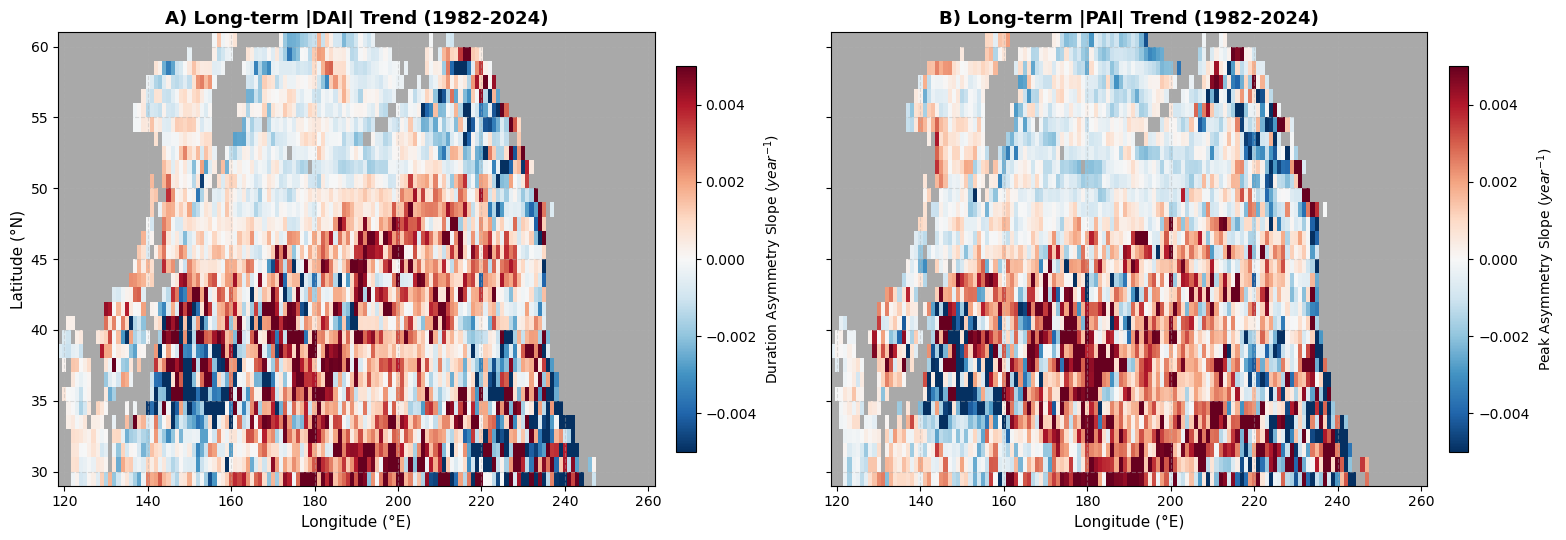

In [13]:
# ==========================================
# 4. Render 1x2 Matrix Panel for Long-term Trends Only
# ==========================================
print(">>> Visualizing 1x2 Long-term Trend Matrix for |DAI| and |PAI|...")

# Colormap configuration (Diverging RdBu_r to separate positive/negative trends)
trend_cmap = 'RdBu_r'

# Setup 1-row, 2-column subplot figure
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5.5), sharex=True, sharey=True)
lon_grid_pac, lat_grid_pac = np.meshgrid(lon_pac, lat_pac)

# Unified Range Setup for Linear Slope Analysis
vmax_trend = 0.005  # Captures trend scales up to +/- 0.005 per year gracefully

plots_config = [
    {
        'data': dai_trend_pac,   
        'ax': axes[0], 
        'title': 'A) Long-term |DAI| Trend (1982-2024)',
        'label': 'Duration Asymmetry Slope ($year^{-1}$)'
    },
    {
        'data': pai_trend_pac,   
        'ax': axes[1], 
        'title': 'B) Long-term |PAI| Trend (1982-2024)',
        'label': 'Peak Asymmetry Slope ($year^{-1}$)'
    }
]

for p in plots_config:
    ax = p['ax']
    mesh = ax.pcolormesh(
        lon_grid_pac, lat_grid_pac, p['data'], 
        cmap=trend_cmap, vmin=-vmax_trend, vmax=vmax_trend, shading='auto'
    )
    ax.set_title(p['title'], fontsize=13, weight='bold')
    
    # Attach optimized horizontal or vertical colorbar directly to its specific panel
    cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', pad=0.03, shrink=0.85)
    cbar.set_label(p['label'], fontsize=10)

# Standardize axis decorations for the 1x2 block frame
for ax in axes:
    ax.set_facecolor('darkgray')  # Highlights landmask areas beautifully
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_xlabel('Longitude (°E)', fontsize=11)

# Apply y-label only to the leftmost axis to keep the figure neat
axes[0].set_ylabel('Latitude (°N)', fontsize=11)

plt.tight_layout()
plt.show()

In [7]:
import os
import glob
import numpy as np
import xarray as xr

# ==========================================
# 1. Path and Data Configurations (North Atlantic)
# ==========================================
print(">>> Collecting file paths for North Atlantic...")
past_files_atl = get_file_list('North_Atlantic', past_years)
present_files_atl = get_file_list('North_Atlantic', present_years)

print(f"  - Atlantic Past files: {len(past_files_atl)} | Present files: {len(present_files_atl)}")

print("\n>>> Loading full 4D datasets for North Atlantic grid-point analysis...")
ds_past_atl = xr.open_mfdataset(past_files_atl, combine='by_coords', chunks={'time_counter': 1, 'deptht': -1})
ds_present_atl = xr.open_mfdataset(present_files_atl, combine='by_coords', chunks={'time_counter': 1, 'deptht': -1})

# Extract horizontal coordinates specific to the North Atlantic domain
lon_atl = ds_past_atl['lon'].values
lat_atl = ds_past_atl['lat'].values
ny_atl, nx_atl = len(lat_atl), len(lon_atl)

# Calculate layer thickness (dz) from vertical depth centerpoints with 300m truncation
depth_atl = ds_past_atl['deptht'].values
bounds_atl = np.zeros(len(depth_atl) + 1)
bounds_atl[1:-1] = (depth_atl[:-1] + depth_atl[1:]) / 2.0
bounds_atl[0] = 0.0
bounds_atl[-1] = depth_atl[-1] + (depth_atl[-1] - bounds_atl[-2])

dz_full_atl = np.diff(bounds_atl)
dz_300_atl = np.zeros_like(dz_full_atl)
max_depth = 300.0  # Integration depth limit (meters)

for k in range(len(depth_atl)):
    z_top = bounds_atl[k]
    z_bot = bounds_atl[k+1]
    
    if z_bot <= max_depth:
        # Entire layer is within upper 300m
        dz_300_atl[k] = dz_full_atl[k]
    elif z_top < max_depth and z_bot > max_depth:
        # Layer straddles the 300m line -> truncate thickness precisely at 300m
        dz_300_atl[k] = max_depth - z_top
    else:
        # Layer is entirely below 300m
        dz_300_atl[k] = 0.0

dz_atl = xr.DataArray(dz_300_atl, dims=['deptht'], coords={'deptht': ds_past_atl['deptht']})

# Calculate Upper 300m OHC map time-series (dropping deeper layers where dz == 0)
print("  - Computing Upper 300m vertical integration for each Atlantic grid point...")
T_past_300_atl = ds_past_atl['votemper'].where(dz_atl > 0, drop=True)
T_present_300_atl = ds_present_atl['votemper'].where(dz_atl > 0, drop=True)
dz_truncated_atl = dz_atl.where(dz_atl > 0, drop=True)

ohc_past_2d_atl = (T_past_300_atl * dz_truncated_atl).sum(dim='deptht', skipna=True) * rho0 * Cp
ohc_present_2d_atl = (T_present_300_atl * dz_truncated_atl).sum(dim='deptht', skipna=True) * rho0 * Cp

# Compute 12-month climatology maps (resulting shape: 12 x lat x lon)
print("  - Generating 12-month Upper 300m climatology grids for Atlantic...")
clim_past_atl = ohc_past_2d_atl.groupby('time_counter.month').mean(dim='time_counter').load()
clim_present_atl = ohc_present_2d_atl.groupby('time_counter.month').mean(dim='time_counter').load()

ds_past_atl.close()
ds_present_atl.close()

# ==========================================
# 2. Grid-Point FFT and Asymmetry Extraction Function
# ==========================================
def compute_asymmetry_maps_atl(clim_grid, ny, nx):
    """Vectorized calculation of |DAI| and |PAI| maps optimized for Atlantic dimensions"""
    data_3d = clim_grid.values
    data_flat = data_3d.reshape(12, -1)
    
    # Store land mask to restore shape later
    land_mask = np.isnan(data_flat.mean(axis=0))
    
    # Fill NaNs temporarily with 0 to prevent FFT corruption on land cells
    data_flat_filled = np.nan_to_num(data_flat, nan=0.0)
    
    # Apply 1D FFT along the monthly axis (axis=0)
    dft_coeffs = np.fft.fft(data_flat_filled, axis=0)
    
    # Harmonic normalization (2 / N)
    h1 = dft_coeffs[1, :] * (2.0 / 12.0)
    h2 = dft_coeffs[2, :] * (2.0 / 12.0)
    
    A1 = np.abs(h1)
    A2 = np.abs(h2)
    
    phi1 = -np.angle(h1)
    phi2 = -np.angle(h2)
    
    theta = 2 * phi1 - phi2
    
    # Avoid zero-division errors over extreme land/missing grids safely
    with np.errstate(divide='ignore', invalid='ignore'):
        amp_ratio = A2 / A1
        dai = amp_ratio * np.abs(np.sin(theta))
        pai = amp_ratio * np.abs(np.cos(theta))
    
    # Re-apply the original ocean-land mask
    dai[land_mask] = np.nan
    pai[land_mask] = np.nan
    
    # Reshape back to the specific Atlantic 2D spatial grid maps
    return dai.reshape(ny, nx), pai.reshape(ny, nx)

print("\n>>> Executing spatial Fourier transform maps for North Atlantic...")
dai_past_atl, pai_past_atl = compute_asymmetry_maps_atl(clim_past_atl, ny_atl, nx_atl)
dai_present_atl, pai_present_atl = compute_asymmetry_maps_atl(clim_present_atl, ny_atl, nx_atl)

# Calculate the differences (Present minus Past) for North Atlantic
dai_diff_atl = dai_present_atl - dai_past_atl
pai_diff_atl = pai_present_atl - pai_past_atl

print("=== Atlantic Grid-Point FFT Computations Completed Successfully! ===")
print("Variables generated: 'dai_past_atl', 'pai_past_atl', 'dai_diff_atl', 'pai_diff_atl' etc.")

>>> Collecting file paths for North Atlantic...
  - Atlantic Past files: 120 | Present files: 120

>>> Loading full 4D datasets for North Atlantic grid-point analysis...
  - Computing Upper 300m vertical integration for each Atlantic grid point...
  - Generating 12-month Upper 300m climatology grids for Atlantic...

>>> Executing spatial Fourier transform maps for North Atlantic...
=== Atlantic Grid-Point FFT Computations Completed Successfully! ===
Variables generated: 'dai_past_atl', 'pai_past_atl', 'dai_diff_atl', 'pai_diff_atl' etc.


>>> Visualizing 3x2 Asymmetry Spatial Matrix for North Atlantic (Upper 300m)...


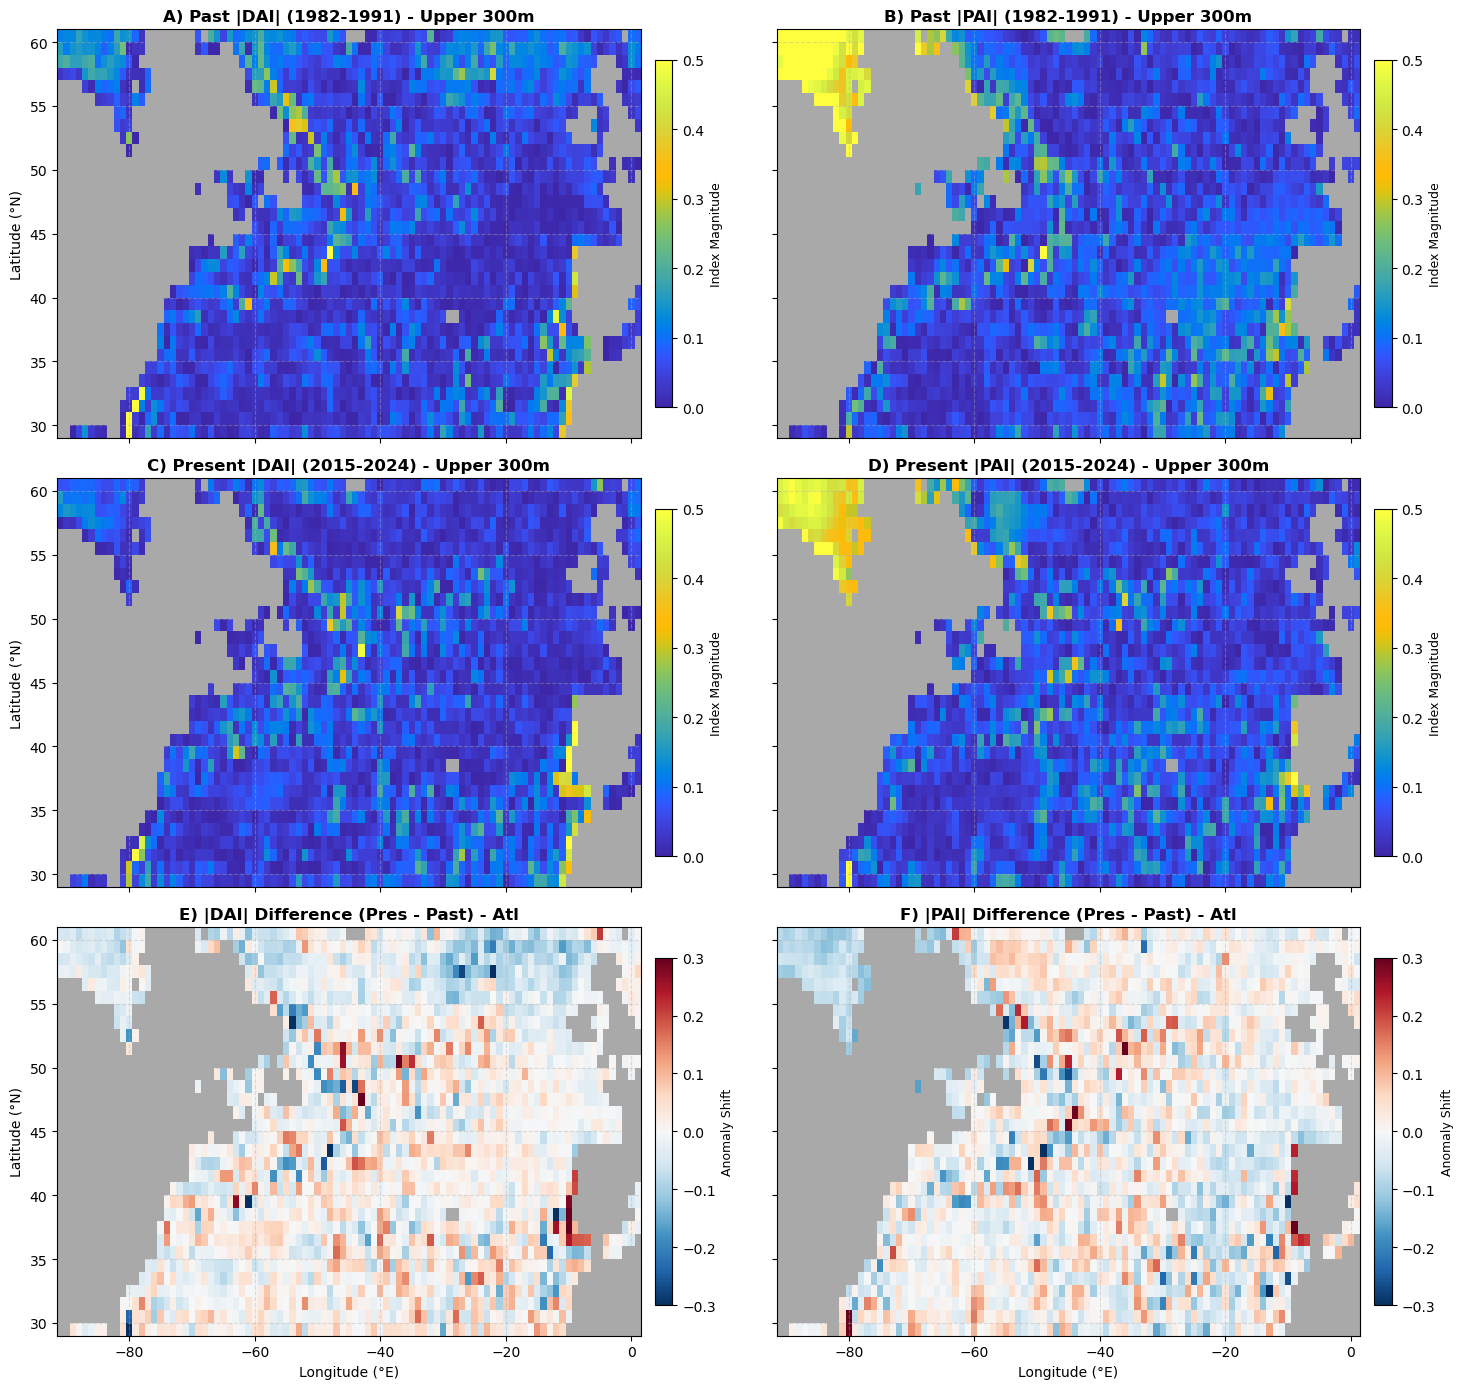

In [8]:
# ==========================================
# 3. Render North Atlantic Matrix using Existing Parula Colormap (Upper 300m)
# ==========================================
print(">>> Visualizing 3x2 Asymmetry Spatial Matrix for North Atlantic (Upper 300m)...")

# Reuse existing parula_cmap and diff_cmap from prior cells
diff_cmap = 'RdBu_r'

# Main Figure Framing
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 14), sharex=True, sharey=True)

# Generate meshgrid using specific North Atlantic horizontal coordinates
lon_grid_atl, lat_grid_atl = np.meshgrid(lon_atl, lat_atl)

# Unified Range Setup
vmax_idx = 0.5    
vmax_diff = 0.3

# Subplot rendering mapped strictly to North Atlantic 300m computed arrays (_atl)
plots_config = [
    # Row 1: Past State (North Atlantic 300m)
    {'data': dai_past_atl,    'ax': axes[0, 0], 'cmap': parula_cmap, 'vmin': 0.0,         'vmax': vmax_idx,  'title': 'A) Past |DAI| (1982-1991) - Upper 300m'},
    {'data': pai_past_atl,    'ax': axes[0, 1], 'cmap': parula_cmap, 'vmin': 0.0,         'vmax': vmax_idx,  'title': 'B) Past |PAI| (1982-1991) - Upper 300m'},
    # Row 2: Present State (North Atlantic 300m)
    {'data': dai_present_atl, 'ax': axes[1, 0], 'cmap': parula_cmap, 'vmin': 0.0,         'vmax': vmax_idx,  'title': 'C) Present |DAI| (2015-2024) - Upper 300m'},
    {'data': pai_present_atl, 'ax': axes[1, 1], 'cmap': parula_cmap, 'vmin': 0.0,         'vmax': vmax_idx,  'title': 'D) Present |PAI| (2015-2024) - Upper 300m'},
    # Row 3: Climate Change Shift (Present - Past)
    {'data': dai_diff_atl,    'ax': axes[2, 0], 'cmap': diff_cmap,   'vmin': -vmax_diff, 'vmax': vmax_diff, 'title': 'E) |DAI| Difference (Pres - Past) - Atl'},
    {'data': pai_diff_atl,    'ax': axes[2, 1], 'cmap': diff_cmap,   'vmin': -vmax_diff, 'vmax': vmax_diff, 'title': 'F) |PAI| Difference (Pres - Past) - Atl'}
]

for p in plots_config:
    ax = p['ax']
    mesh = ax.pcolormesh(lon_grid_atl, lat_grid_atl, p['data'], cmap=p['cmap'], vmin=p['vmin'], vmax=p['vmax'], shading='auto')
    ax.set_title(p['title'], fontsize=12, weight='bold')
    
    cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', pad=0.02, shrink=0.85)
    if 'Difference' in p['title']:
        cbar.set_label('Anomaly Shift', fontsize=9)
    else:
        cbar.set_label('Index Magnitude', fontsize=9)

# Standardize axis decorations for the entire matrix frame
for ax in axes.flatten():
    ax.set_facecolor('darkgray') # Highlights landmask areas beautifully
    ax.grid(True, linestyle='--', alpha=0.4)

# Apply specific labels only to boundary edges to keep plot uncluttered
for row in range(3):
    axes[row, 0].set_ylabel('Latitude (°N)', fontsize=10)
for col in range(2):
    axes[2, col].set_xlabel('Longitude (°E)', fontsize=10)

plt.tight_layout()
plt.show()

In [15]:
import os
import glob
import numpy as np
import xarray as xr

# ==========================================
# 1. Multi-Year Path and Domain Setup (North Atlantic)
# ==========================================
print(">>> Preparing multi-year grid-point trend analysis for North Atlantic...")
all_years = range(1982, 2025)  # 1982 ~ 2024 (43 years)
max_depth = 300.0

# 1.1 Extract dimensions using an Atlantic template file
sample_files_atl = get_single_year_files('North_Atlantic', 1982)
ds_template_atl = xr.open_dataset(sample_files_atl[0])
lon_atl = ds_template_atl['lon'].values
lat_atl = ds_template_atl['lat'].values
ny_atl, nx_atl = len(lat_atl), len(lon_atl)
ds_template_atl.close()

# Allocate 3D arrays to store annual maps: (Years, Lat, Lon) for Atlantic
num_years = len(all_years)
annual_dai_3d_atl = np.full((num_years, ny_atl, nx_atl), np.nan)
annual_pai_3d_atl = np.full((num_years, ny_atl, nx_atl), np.nan)

# ==========================================
# 2. Annual Loop for Fourier Grid Mapping (Atlantic)
# ==========================================
for y_idx, yr in enumerate(all_years):
    files = get_single_year_files('North_Atlantic', yr)
    if len(files) != 12:
        print(f"  - Year {yr}: [Skip] Missing months for Atlantic.")
        continue
        
    print(f"  - Extracting annual asymmetry grids for Atlantic - year: {yr}...")
    ds_yr = xr.open_mfdataset(files, combine='by_coords', chunks={'time_counter': 1, 'deptht': -1})
    
    # Precise 300m vertical integration setup
    depth = ds_yr['deptht'].values
    bounds = np.zeros(len(depth) + 1)
    bounds[1:-1] = (depth[:-1] + depth[1:]) / 2.0
    bounds[0] = 0.0
    bounds[-1] = depth[-1] + (depth[-1] - bounds[-2])
    dz_full = np.diff(bounds)
    
    dz_300 = np.zeros_like(dz_full)
    for k in range(len(depth)):
        if bounds[k+1] <= max_depth:
            dz_300[k] = dz_full[k]
        elif bounds[k] < max_depth and bounds[k+1] > max_depth:
            dz_300[k] = max_depth - bounds[k]
            
    dz = xr.DataArray(dz_300, dims=['deptht'], coords={'deptht': ds_yr['deptht']})
    
    # 2D Upper 300m OHC Mapping for the 12 months
    T_300 = ds_yr['votemper'].where(dz > 0, drop=True)
    dz_trunc = dz.where(dz > 0, drop=True)
    ohc_2d_12months = (T_300 * dz_trunc).sum(dim='deptht', skipna=True).load() * rho0 * Cp
    ds_yr.close()
    
    # Flatten grid arrays for vectorized 1D FFT along months axis (axis=0)
    data_flat = ohc_2d_12months.values.reshape(12, -1)
    # Using .all(axis=0) to ensure land_mask only flags true grids where data is missing all 12 months
    land_mask = np.isnan(data_flat).all(axis=0)
    data_filled = np.nan_to_num(data_flat, nan=0.0)
    
    # FFT
    dft_coeffs = np.fft.fft(data_filled, axis=0)
    h1 = dft_coeffs[1, :] * (2.0 / 12.0)
    h2 = dft_coeffs[2, :] * (2.0 / 12.0)
    
    A1, A2 = np.abs(h1), np.abs(h2)
    phi1, phi2 = -np.angle(h1), -np.angle(h2)
    theta = 2 * phi1 - phi2
    
    with np.errstate(divide='ignore', invalid='ignore'):
        amp_ratio = A2 / A1
        dai_flat = amp_ratio * np.abs(np.sin(theta))
        pai_flat = amp_ratio * np.abs(np.cos(theta))
        
    dai_flat[land_mask] = np.nan
    pai_flat[land_mask] = np.nan
    
    # Store results into the multi-year Atlantic matrix
    annual_dai_3d_atl[y_idx, :, :] = dai_flat.reshape(ny_atl, nx_atl)
    annual_pai_3d_atl[y_idx, :, :] = pai_flat.reshape(ny_atl, nx_atl)

# ==========================================
# 3. Vectorized Linear Regression (Robust Trend extraction)
# ==========================================
print("\n>>> Computing pixel-by-pixel linear trends across 43 years for Atlantic...")
years_arr = np.array(all_years)

# Reshape (Years, Lat, Lon) -> (Years, Lat*Lon)
dai_flat_ts_atl = annual_dai_3d_atl.reshape(num_years, -1)
pai_flat_ts_atl = annual_pai_3d_atl.reshape(num_years, -1)

dai_trend_flat_atl = np.full(dai_flat_ts_atl.shape[1], np.nan)
pai_trend_flat_atl = np.full(pai_flat_ts_atl.shape[1], np.nan)

# Linear slope estimation using nan-skipping
for p_idx in range(dai_flat_ts_atl.shape[1]):
    y_dai = dai_flat_ts_atl[:, p_idx]
    y_pai = pai_flat_ts_atl[:, p_idx]
    
    valid_dai = ~np.isnan(y_dai)
    valid_pai = ~np.isnan(y_pai)
    
    if np.sum(valid_dai) >= 5:  
        dai_trend_flat_atl[p_idx] = np.polyfit(years_arr[valid_dai], y_dai[valid_dai], 1)[0]
        
    if np.sum(valid_pai) >= 5:
        pai_trend_flat_atl[p_idx] = np.polyfit(years_arr[valid_pai], y_pai[valid_pai], 1)[0]

# Reshape trend arrays back to 2D
dai_trend_atl = dai_trend_flat_atl.reshape(ny_atl, nx_atl)
pai_trend_atl = pai_trend_flat_atl.reshape(ny_atl, nx_atl) # matching Atlantic grids

# Quick validation check in terminal to avoid gray plot issue
print(f"  - Max DAI Atlantic Trend found: {np.nanmax(dai_trend_atl):.4e}")
print(f"  - Min DAI Atlantic Trend found: {np.nanmin(dai_trend_atl):.4e}")
print(f"  - Non-NaN Grid Count (Atlantic): {np.count_nonzero(~np.isnan(dai_trend_atl))} / {ny_atl * nx_atl}")
print("=== Long-term Atlantic Trend Calculation Complete! ===")
print("Variables generated: 'dai_trend_atl' and 'pai_trend_atl' (unit: /year)")

>>> Preparing multi-year grid-point trend analysis for North Atlantic...
  - Extracting annual asymmetry grids for Atlantic - year: 1982...
  - Extracting annual asymmetry grids for Atlantic - year: 1983...
  - Extracting annual asymmetry grids for Atlantic - year: 1984...
  - Extracting annual asymmetry grids for Atlantic - year: 1985...
  - Extracting annual asymmetry grids for Atlantic - year: 1986...
  - Extracting annual asymmetry grids for Atlantic - year: 1987...
  - Extracting annual asymmetry grids for Atlantic - year: 1988...
  - Extracting annual asymmetry grids for Atlantic - year: 1989...
  - Extracting annual asymmetry grids for Atlantic - year: 1990...
  - Extracting annual asymmetry grids for Atlantic - year: 1991...
  - Year 1992: [Skip] Missing months for Atlantic.
  - Year 1993: [Skip] Missing months for Atlantic.
  - Year 1994: [Skip] Missing months for Atlantic.
  - Year 1995: [Skip] Missing months for Atlantic.
  - Year 1996: [Skip] Missing months for Atlantic.
  

>>> Visualizing 1x2 Long-term Trend Matrix for North Atlantic (|DAI| & |PAI|)...


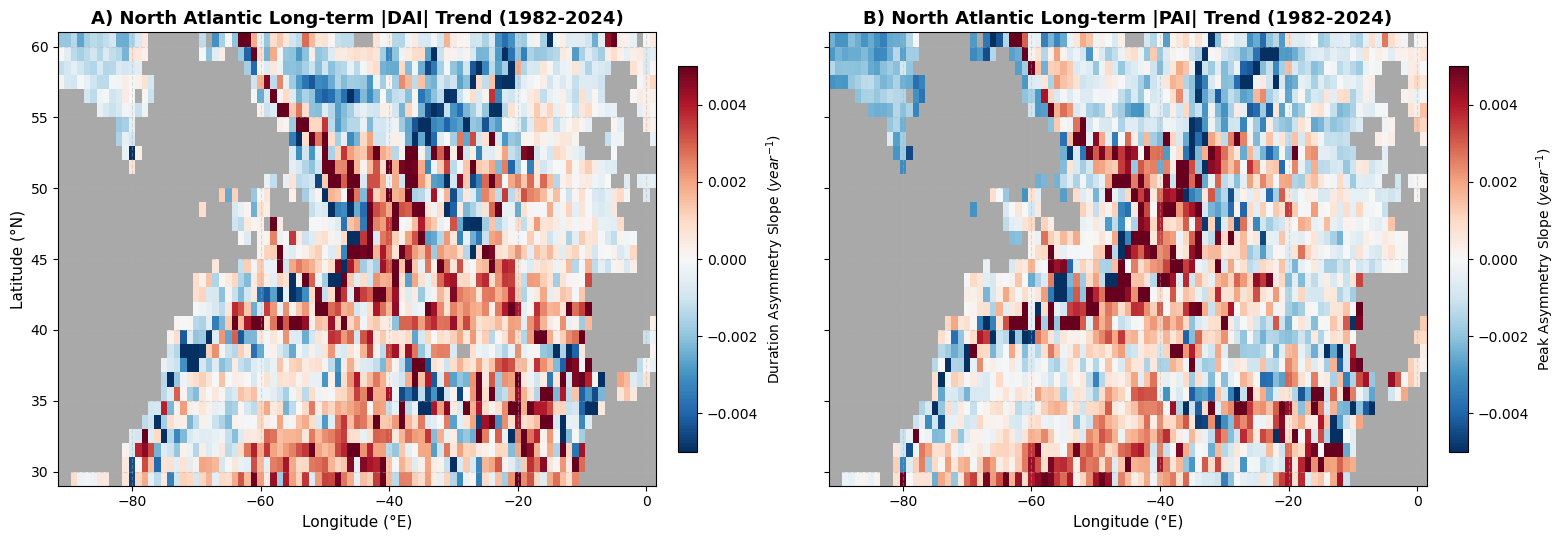

In [16]:
# ==========================================
# 4. Render 1x2 Matrix Panel for North Atlantic Long-term Trends Only
# ==========================================
print(">>> Visualizing 1x2 Long-term Trend Matrix for North Atlantic (|DAI| & |PAI|)...")

# Colormap configuration (Diverging RdBu_r to separate positive/negative trends)
trend_cmap = 'RdBu_r'

# Setup 1-row, 2-column subplot figure
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5.5), sharex=True, sharey=True)

# Generate meshgrid using specific North Atlantic horizontal coordinates (_atl)
lon_grid_atl, lat_grid_atl = np.meshgrid(lon_atl, lat_atl)

# Unified Range Setup for Linear Slope Analysis
vmax_trend = 0.005  # Captures trend scales up to +/- 0.005 per year gracefully

plots_config_atl = [
    {
        'data': dai_trend_atl,   
        'ax': axes[0], 
        'title': 'A) North Atlantic Long-term |DAI| Trend (1982-2024)',
        'label': 'Duration Asymmetry Slope ($year^{-1}$)'
    },
    {
        'data': pai_trend_atl,   
        'ax': axes[1], 
        'title': 'B) North Atlantic Long-term |PAI| Trend (1982-2024)',
        'label': 'Peak Asymmetry Slope ($year^{-1}$)'
    }
]

for p in plots_config_atl:
    ax = p['ax']
    mesh = ax.pcolormesh(
        lon_grid_atl, lat_grid_atl, p['data'], 
        cmap=trend_cmap, vmin=-vmax_trend, vmax=vmax_trend, shading='auto'
    )
    ax.set_title(p['title'], fontsize=13, weight='bold')
    
    # Attach optimized colorbar directly to its specific panel
    cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', pad=0.03, shrink=0.85)
    cbar.set_label(p['label'], fontsize=10)

# Standardize axis decorations for the 1x2 block frame
for ax in axes:
    ax.set_facecolor('darkgray')  # Highlights landmask areas beautifully
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_xlabel('Longitude (°E)', fontsize=11)

# Apply y-label only to the leftmost axis to keep the figure neat
axes[0].set_ylabel('Latitude (°N)', fontsize=11)

plt.tight_layout()
plt.show()

>>> Generating Mosaic Box Seasonal Cycles for North Pacific...


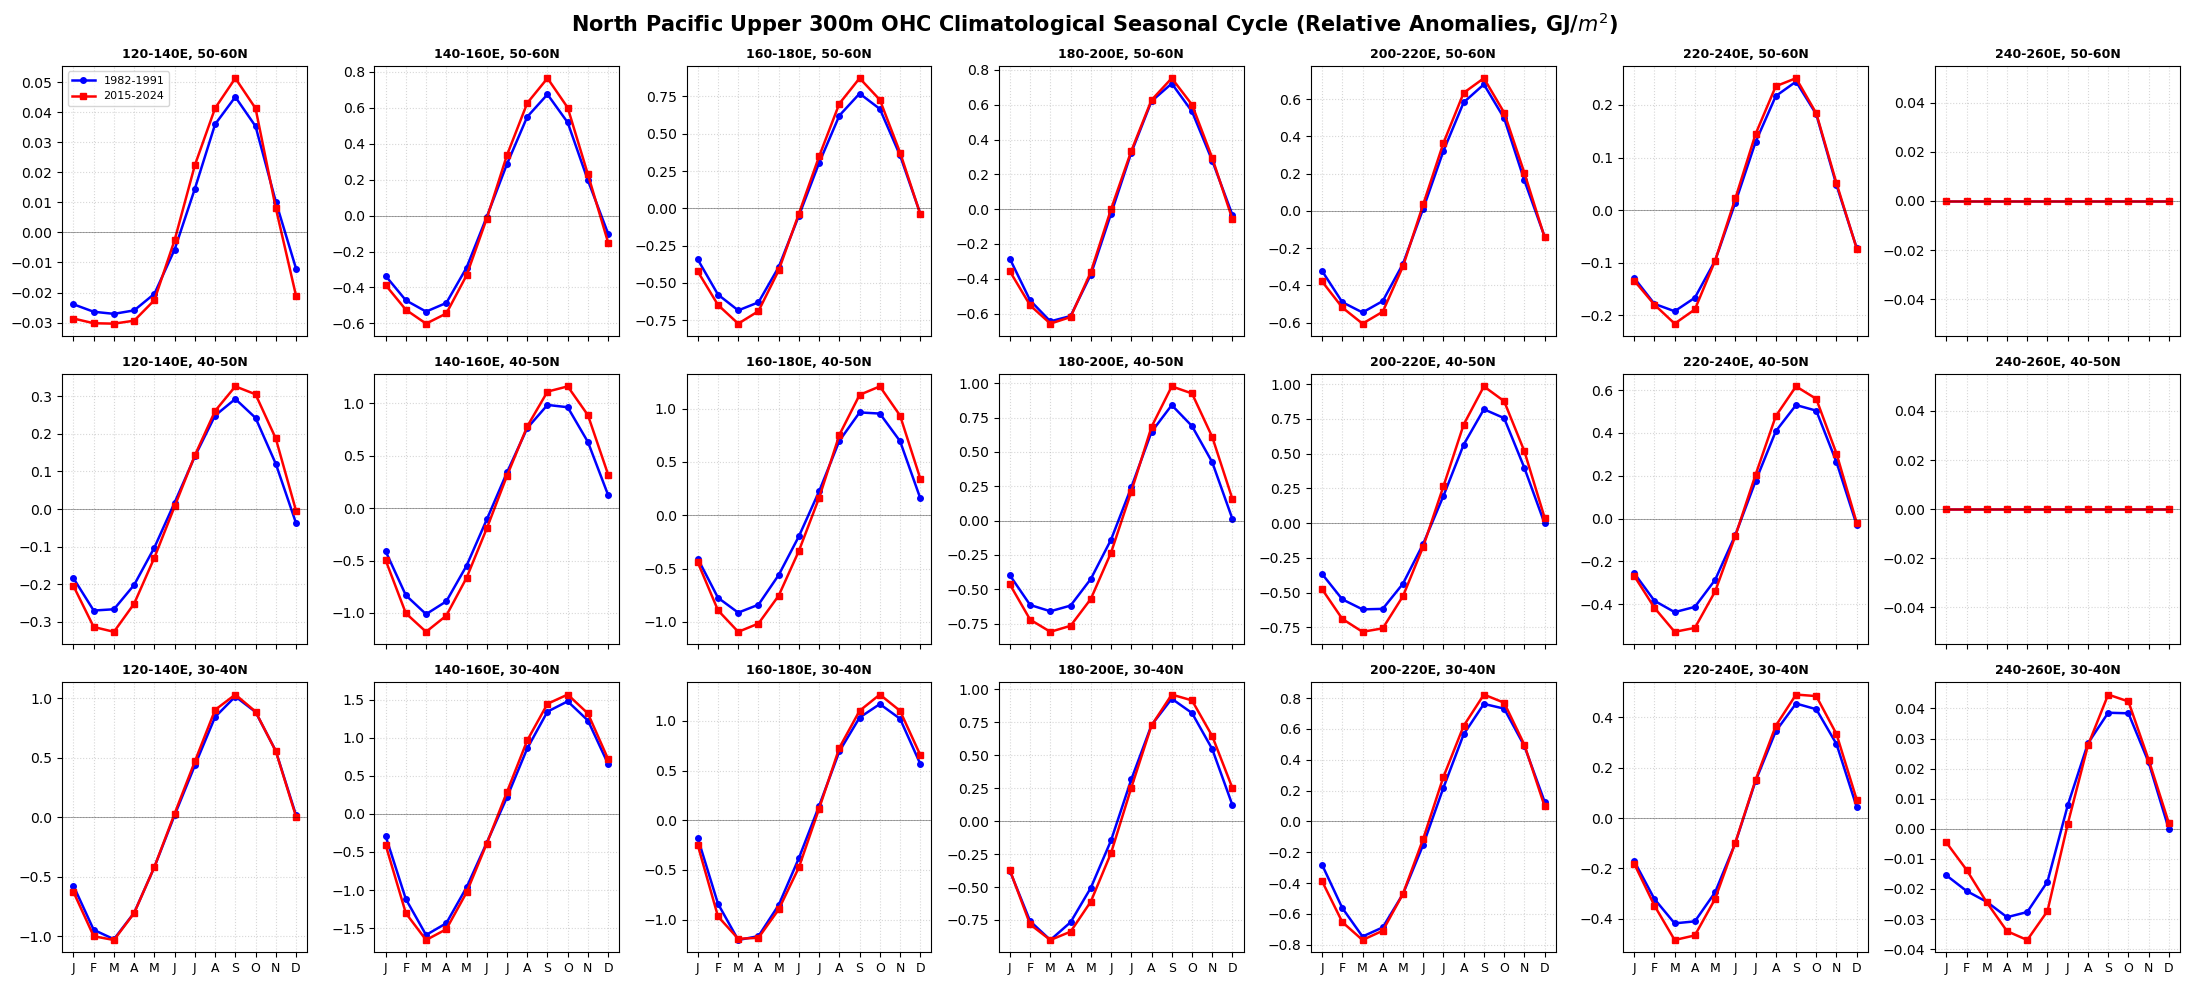

In [19]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ==========================================
# 1. Coordinate Boundaries Setup (North Pacific)
# ==========================================
lon_bins_pac = np.arange(120, 280, 20)  # 120, 140, 160, 180, 200, 220, 240, 260
lat_bins_pac = np.arange(30, 70, 10)    # 30, 40, 50, 60

n_lon_pac = len(lon_bins_pac) - 1  # 7 columns
n_lat_pac = len(lat_bins_pac) - 1  # 3 rows

# Setup 3 rows x 7 columns matrix figure (Matches Latitudinal layers)
# Note: rows are inverted [axes[0,:] is 50-60N, axes[2,:] is 30-40N]
fig, axes = plt.subplots(nrows=n_lat_pac, ncols=n_lon_pac, figsize=(22, 10), sharex=True)

months_axis = np.arange(1, 13)
month_labels = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

print(">>> Generating Mosaic Box Seasonal Cycles for North Pacific...")

# 2. Loop through Latitude layers (Top rows = Higher Latitudes)
for r_idx in range(n_lat_pac):
    # Invert index so row 0 plots 50-60N and row 2 plots 30-40N
    lat_min = lat_bins_pac[n_lat_pac - 1 - r_idx]
    lat_max = lat_bins_pac[n_lat_pac - r_idx]
    
    # Loop through Longitude bins (Left to Right)
    for c_idx in range(n_lon_pac):
        lon_min = lon_bins_pac[c_idx]
        lon_max = lon_bins_pac[c_idx + 1]
        
        ax = axes[r_idx, c_idx]
        
        # 2.1 Slice Area Box for Past and Present
        box_past = clim_past_pac.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))
        box_pres = clim_present_pac.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))
        
        # 2.2 Spatial Mean with Latitude Weighting (Skip if all landmass)
        if box_past.dropna(dim='lat', how='all').size == 0:
            ax.set_facecolor('lightgray')
            ax.text(0.5, 0.5, 'Land', ha='center', va='center', transform=ax.transAxes, color='gray')
            continue
            
        weights_past = np.cos(np.deg2rad(box_past['lat']))
        weights_pres = np.cos(np.deg2rad(box_pres['lat']))
        
        # Scale to GJ/m^2 directly for easy tracking
        ts_past = box_past.weighted(weights_past).mean(dim=['lat', 'lon'], skipna=True).load() / 1e9
        ts_pres = box_pres.weighted(weights_pres).mean(dim=['lat', 'lon'], skipna=True).load() / 1e9
        
        # To strictly view the "Shape/Phase Asymmetry Change" like the paper, 
        # let's subtract the annual mean from each series (Relative Anomalies)
        anom_past = ts_past - ts_past.mean()
        anom_pres = ts_pres - ts_pres.mean()
        
        # 2.3 Plotting Curves
        ax.plot(months_axis, anom_past, marker='o', markersize=4, color='blue', linewidth=1.8, label='1982-1991')
        ax.plot(months_axis, anom_pres, marker='s', markersize=4, color='red', linewidth=1.8, label='2015-2024')
        ax.axhline(0, color='black', linestyle='-', linewidth=0.6, alpha=0.4)
        
        # Formatting individual mini subplots
        ax.set_title(f"{lon_min}-{lon_max}E, {lat_min}-{lat_max}N", fontsize=9, weight='bold')
        ax.grid(True, linestyle=':', alpha=0.5)
        ax.set_xticks(months_axis)
        
        if r_idx == n_lat_pac - 1:  # Only bottom row gets X tick labels
            ax.set_xticklabels(month_labels, fontsize=9)
            
        # Add legend only to the top-leftmost valid ocean block
        if r_idx == 0 and c_idx == 0:
            ax.legend(fontsize=8, loc='upper left')

plt.suptitle('North Pacific Upper 300m OHC Climatological Seasonal Cycle (Relative Anomalies, GJ/$m^2$)', fontsize=15, weight='bold', y=0.98)
plt.tight_layout()
plt.show()

>>> Generating Mosaic Box Seasonal Cycles for North Atlantic... (Detected longitude style: -180 to 180)


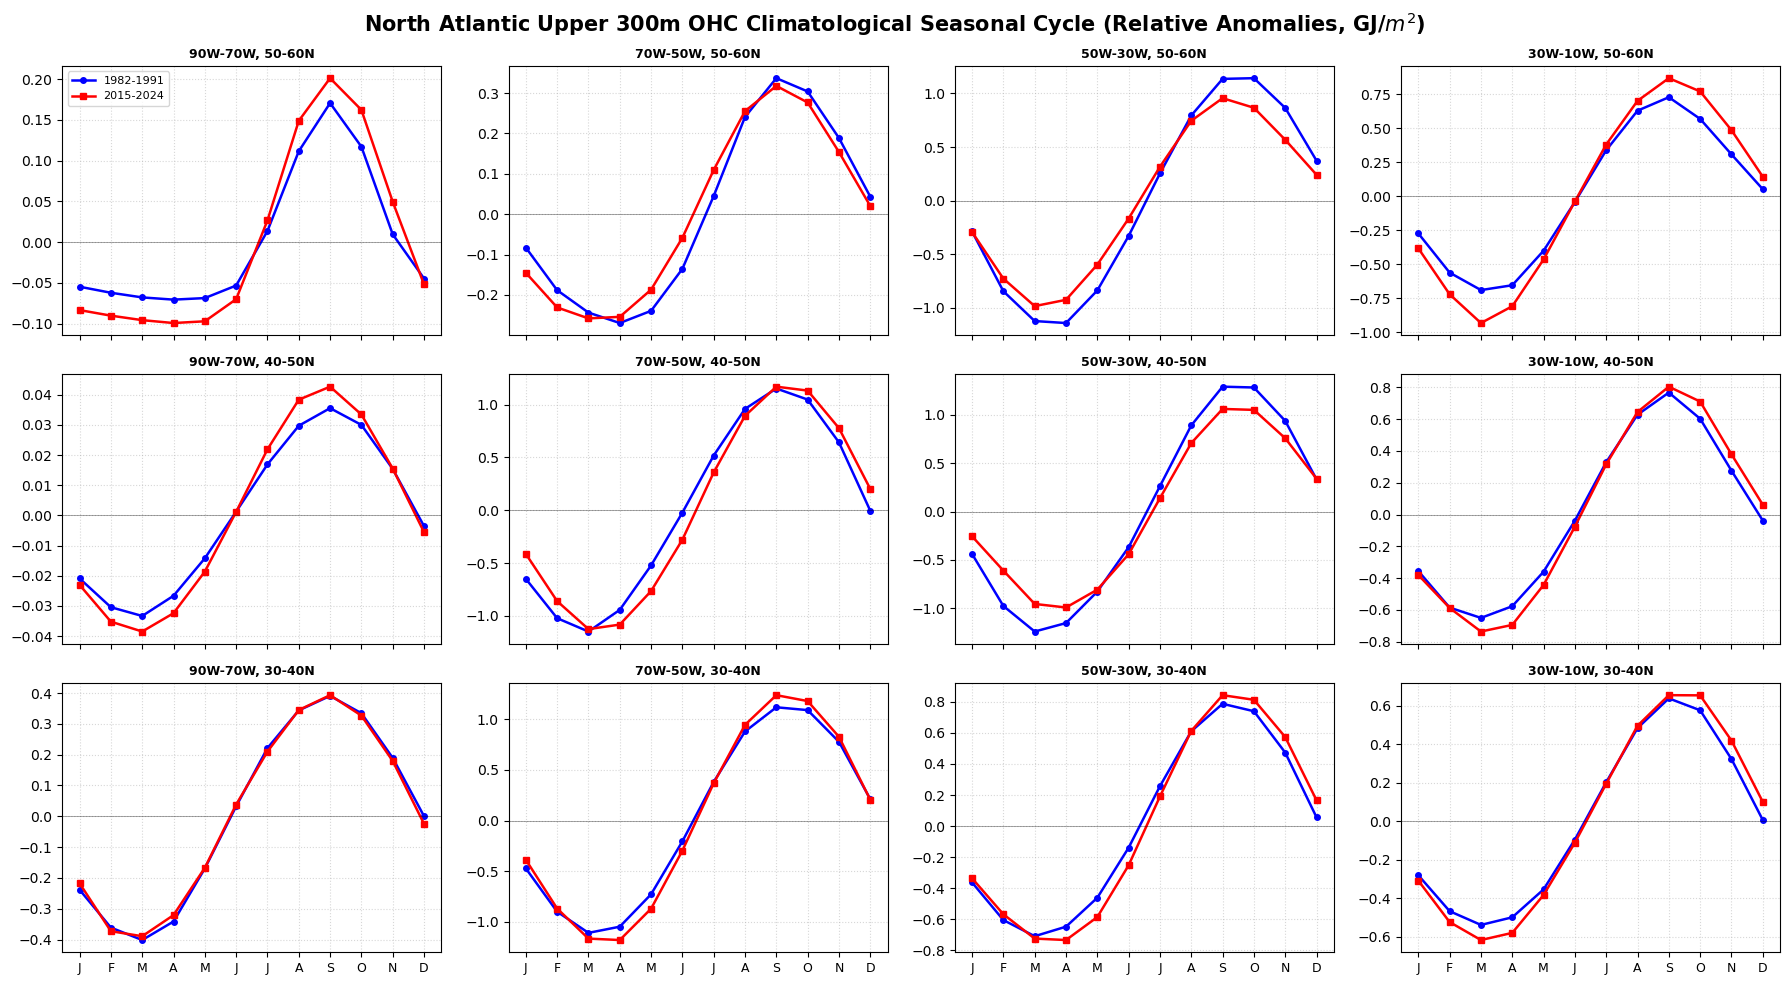

In [23]:
# ==========================================
# 3. Coordinate Boundaries Setup (North Atlantic - Robust Version)
# ==========================================
# Let's check the coordinate system style automatically from your array
sample_lon_val = float(clim_past_atl['lon'].values[0])
is_180_format = sample_lon_val < 0 or any(clim_past_atl['lon'].values < 0)

# Standard 0-360 standard bin edges
lon_bins_atl = np.arange(270, 370, 20)  # 270, 290, 310, 330, 350, 370
lat_bins_atl = np.arange(30, 70, 10)    # 30, 40, 50, 60

n_lon_atl = len(lon_bins_atl) - 1  # 5 columns
n_lat_atl = len(lat_bins_atl) - 1  # 3 rows

fig, axes = plt.subplots(nrows=n_lat_atl, ncols=n_lon_atl, figsize=(18, 10), sharex=True)
months_axis = np.arange(1, 13)
month_labels = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

print(f">>> Generating Mosaic Box Seasonal Cycles for North Atlantic... (Detected longitude style: {'-180 to 180' if is_180_format else '0 to 360'})")

for r_idx in range(n_lat_atl):
    lat_min = lat_bins_atl[n_lat_atl - 1 - r_idx]
    lat_max = lat_bins_atl[n_lat_atl - r_idx]
    
    for c_idx in range(n_lon_atl):
        lon_min = lon_bins_atl[c_idx]
        lon_max = lon_bins_atl[c_idx + 1]
        if lon_max > 360: 
            lon_max = 360
            
        ax = axes[r_idx, c_idx]
        
        # -------------------------------------------------------------
        # Coordinate System Adapter Line
        # -------------------------------------------------------------
        if is_180_format:
            # Convert 270~360E boundaries to -90~0W boundaries
            slice_lon_min = lon_min - 360 if lon_min > 180 else lon_min
            slice_lon_max = lon_max - 360 if lon_max > 180 else lon_max
            
            # Ensure slicing order is always ascending (left to right)
            box_lon_min = min(slice_lon_min, slice_lon_max)
            box_lon_max = max(slice_lon_min, slice_lon_max)
        else:
            box_lon_min = lon_min
            box_lon_max = lon_max
            
        # Slice Area Box safely
        # Slice Area Box safely (수정된 라인)
        box_past = clim_past_atl.sel(lon=slice(box_lon_min, box_lon_max), lat=slice(lat_min, lat_max))
        box_pres = clim_present_atl.sel(lon=slice(box_lon_min, box_lon_max), lat=slice(lat_min, lat_max))
        
        # Double check if the sliced subset array is completely empty or filled with NaNs
        if box_past.size == 0 or np.isnan(box_past.values).all():
            ax.set_facecolor('darkgray')
            # Convert to display text (e.g., 270E-290E -> 90W-70W)
            disp_lon_min = f"{360-lon_min}°W" if lon_min > 180 else f"{lon_min}°E"
            disp_lon_max = f"{360-lon_max}°W" if lon_max > 180 else f"{lon_max}°E"
            ax.set_title(f"{disp_lon_min}-{disp_lon_max}\n{lat_min}-{lat_max}°N", fontsize=8, color='black')
            ax.text(0.5, 0.5, 'No Ocean Data\n(Land/Out)', ha='center', va='center', transform=ax.transAxes, color='yellow', fontsize=8)
            continue
            
        # Compute area-weighted average
        weights_past = np.cos(np.deg2rad(box_past['lat']))
        weights_pres = np.cos(np.deg2rad(box_pres['lat']))
        
        ts_past = box_past.weighted(weights_past).mean(dim=['lat', 'lon'], skipna=True).load() / 1e9
        ts_pres = box_pres.weighted(weights_pres).mean(dim=['lat', 'lon'], skipna=True).load() / 1e9
        
        # Relative Anomalies
        anom_past = ts_past - ts_past.mean()
        anom_pres = ts_pres - ts_pres.mean()
        
        # Plot lines
        ax.plot(months_axis, anom_past, marker='o', markersize=4, color='blue', linewidth=1.8, label='1982-1991')
        ax.plot(months_axis, anom_pres, marker='s', markersize=4, color='red', linewidth=1.8, label='2015-2024')
        ax.axhline(0, color='black', linestyle='-', linewidth=0.6, alpha=0.4)
        
        # Subplot Titles with traditional Atlantic notations
        disp_lon_min = f"{360-lon_min}W" if lon_min > 180 else f"{lon_min}E"
        disp_lon_max = f"{360-lon_max}W" if lon_max > 180 else f"{lon_max}E"
        ax.set_title(f"{disp_lon_min}-{disp_lon_max}, {lat_min}-{lat_max}N", fontsize=9, weight='bold')
        ax.grid(True, linestyle=':', alpha=0.5)
        ax.set_xticks(months_axis)
        
        if r_idx == n_lat_atl - 1:
            ax.set_xticklabels(month_labels, fontsize=9)
            
        if r_idx == 0 and c_idx == 0:
            ax.legend(fontsize=8, loc='upper left')

plt.suptitle('North Atlantic Upper 300m OHC Climatological Seasonal Cycle (Relative Anomalies, GJ/$m^2$)', fontsize=15, weight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [17]:
import numpy as np
import xarray as xr

def calculate_gridwise_r2(clim_grid, ny, nx):
    """
    Computes grid-point R2 tracking how well H1 + H2 fourier curve explains the actual cycle.
    """
    # Shape: (12, lat, lon) -> (12, lat*lon)
    data_3d = clim_grid.values
    data_flat = data_3d.reshape(12, -1)
    
    # Track land mask
    land_mask = np.isnan(data_flat).all(axis=0)
    data_filled = np.nan_to_num(data_flat, nan=0.0)
    
    # 1. Total Sum of Squares (SST): Sum of (y_actual - y_mean)^2
    grid_means = data_filled.mean(axis=0)  # A0 mean state per pixel
    sst = np.sum((data_filled - grid_means)**2, axis=0)
    
    # 2. Fourier Reconstruction (A0 + H1 + H2)
    dft_coeffs = np.fft.fft(data_filled, axis=0)
    
    # Time axis arrays matching the 12 months (t = 1, 2, ..., 12)
    t = np.arange(1, 13)[:, np.newaxis]
    omega = 2 * np.pi / 12.0
    
    # Extract components
    h1 = dft_coeffs[1, :] * (2.0 / 12.0)
    h2 = dft_coeffs[2, :] * (2.0 / 12.0)
    
    A1, A2 = np.abs(h1), np.abs(h2)
    phi1, phi2 = -np.angle(h1), -np.angle(h2)
    
    # Reconstruct the 12-month fitted curve per pixel
    fit_curve = (grid_means + 
                 A1 * np.cos(omega * t - phi1) + 
                 A2 * np.cos(2 * omega * t - phi2))
    
    # 3. Residual Sum of Squares (SSR): Sum of (y_actual - y_fitted)^2
    ssr = np.sum((data_filled - fit_curve)**2, axis=0)
    
    # 4. Calculate R2 = 1 - (SSR / SST)
    with np.errstate(divide='ignore', invalid='ignore'):
        r2 = 1.0 - (ssr / sst)
        # Handle edge cases where variance is exactly zero
        r2[sst == 0] = np.nan 
        
    # Re-apply ocean mask
    r2[land_mask] = np.nan
    
    return r2.reshape(ny, nx)

print(">>> Computing grid-wise R2 maps for Present Period (2015-2024)...")
# Calculate for both basins using the upper 300m climatology matrices computed before
r2_map_pac = calculate_gridwise_r2(clim_present_pac, ny_pac, nx_pac)
r2_map_atl = calculate_gridwise_r2(clim_present_atl, ny_atl, nx_atl)

print(f"  - Pacific R2  [Max: {np.nanmax(r2_map_pac):.3f} | Min: {np.nanmin(r2_map_pac):.3f}]")
print(f"  - Atlantic R2 [Max: {np.nanmax(r2_map_atl):.3f} | Min: {np.nanmin(r2_map_atl):.3f}]")

>>> Computing grid-wise R2 maps for Present Period (2015-2024)...
  - Pacific R2  [Max: 0.731 | Min: 0.128]
  - Atlantic R2 [Max: 0.732 | Min: 0.464]



>>> Plotting 1x2 Grid-wise R2 Matrix for Pacific and Atlantic...


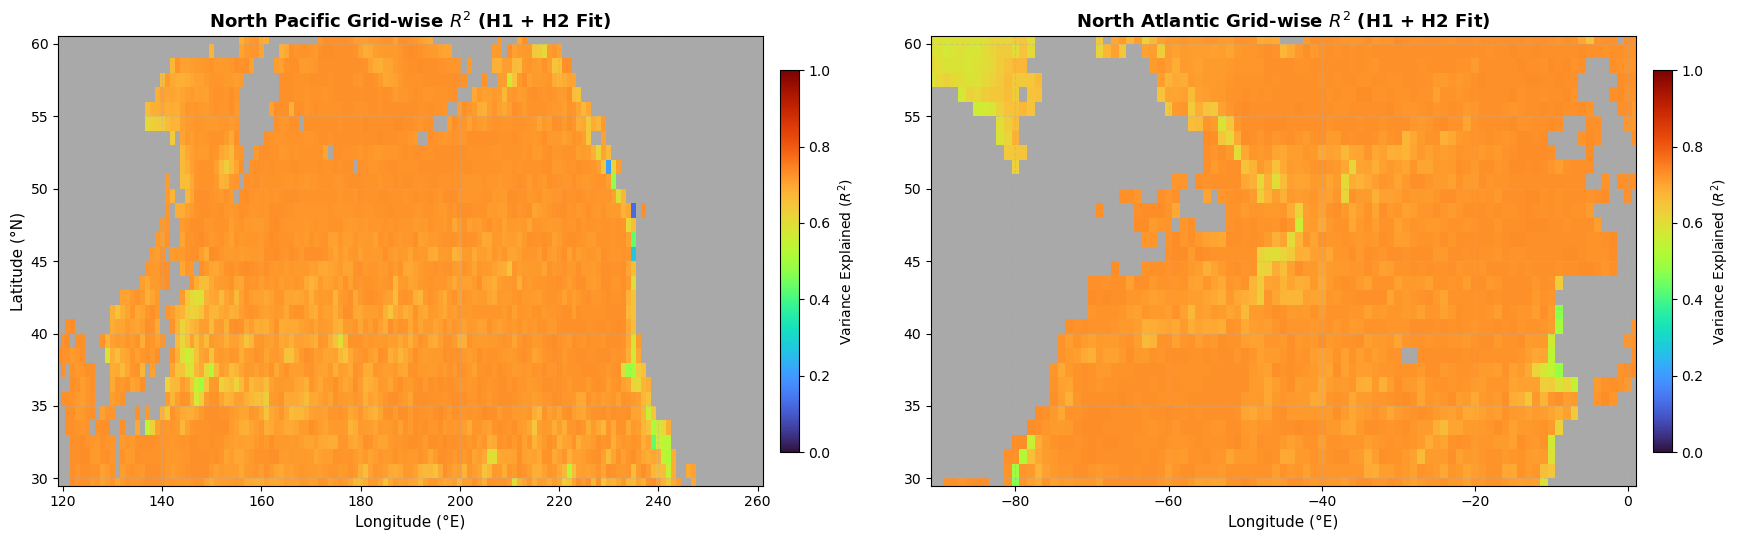

In [18]:
import matplotlib.pyplot as plt

print("\n>>> Plotting 1x2 Grid-wise R2 Matrix for Pacific and Atlantic...")

# Main Figure Framing (1 row, 2 columns)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 5.5))

# Generate individual coordinate meshgrids
lon_grid_pac, lat_grid_pac = np.meshgrid(lon_pac, lat_pac)
lon_grid_atl, lat_grid_atl = np.meshgrid(lon_atl, lat_atl)

# Setup layout parameters matching the requested paper plot style
r2_cmap = 'turbo'  # Excellent mapping resolution for 0 to 1 scales

# -----------------------------------------------------------------
# Panel A: North Pacific Grid-wise R2
# -----------------------------------------------------------------
ax0 = axes[0]
mesh0 = ax0.pcolormesh(lon_grid_pac, lat_grid_pac, r2_map_pac, cmap=r2_cmap, vmin=0.0, vmax=1.0, shading='auto')
ax0.set_title('North Pacific Grid-wise $R^2$ (H1 + H2 Fit)', fontsize=13, weight='bold')
ax0.set_xlabel('Longitude (°E)', fontsize=11)
ax0.set_ylabel('Latitude (°N)', fontsize=11)
ax0.set_xlim(lon_pac.min(), lon_pac.max())
ax0.set_ylim(lat_pac.min(), lat_pac.max())

cbar0 = fig.colorbar(mesh0, ax=ax0, orientation='vertical', pad=0.02, shrink=0.85)
cbar0.set_label('Variance Explained ($R^2$)', fontsize=10)

# -----------------------------------------------------------------
# Panel B: North Atlantic Grid-wise R2
# -----------------------------------------------------------------
ax1 = axes[1]
mesh1 = ax1.pcolormesh(lon_grid_atl, lat_grid_atl, r2_map_atl, cmap=r2_cmap, vmin=0.0, vmax=1.0, shading='auto')
ax1.set_title('North Atlantic Grid-wise $R^2$ (H1 + H2 Fit)', fontsize=13, weight='bold')
ax1.set_xlabel('Longitude (°E)', fontsize=11)
ax1.set_xlim(lon_atl.min(), lon_atl.max())
ax1.set_ylim(lat_atl.min(), lat_atl.max())

cbar1 = fig.colorbar(mesh1, ax=ax1, orientation='vertical', pad=0.02, shrink=0.85)
cbar1.set_label('Variance Explained ($R^2$)', fontsize=10)

# Standardize axis decorations across both panels
for ax in axes:
    ax.set_facecolor('darkgray')  # Keeps land masks beautifully clean
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()